# ****USDJPY TREND PREDICTION USING TECHNICAL INDICATORS AND CLASSICAL MACHINE LEARNING(2000 - 2006)****

**1. Overview**

The foreign exchange (Forex) market is the largest financial market in the world, 
where exchange rates fluctuate due to economic conditions, monetary policies, and market sentiment. 
Predicting market trends is challenging because of the dynamic nature of financial markets. 
This project aims to predict the daily trend (Bullish or Bearish) of the USD/JPY currency pair 
using historical daily price data from Yahoo Finance. The study applies Exploratory Data Analysis (EDA), 
technical indicator feature engineering, and classical machine learning models to develop and evaluate a trend prediction model

**2. Business Problem**

Forex traders rely on technical analysis to make trading decisions,
but interpreting multiple indicators simultaneously can be difficult and subjective. 
This project investigates whether technical indicators combined with 
classical machine learning algorithms can improve the prediction of the next-day USD/JPY market trend (Bullish or Bearish),
thereby supporting more informed trading decisions.

**3. Aim**

To develop a machine learning model that predicts the next-day trend of the USD/JPY currency pair
using technical indicators derived from historical daily price data.

**4. Objectives**

Collect historical USD/JPY daily data from Yahoo Finance.
Perform Exploratory Data Analysis (EDA).
Generate technical indicators through feature engineering.
Build classification models to predict Bullish or Bearish trends.
Compare model performance using evaluation metrics.
Identify the most important features influencing trend prediction.

**5. Python Workflow**

- Import Libraries

- Download USD/JPY Data from Yahoo Finance

- Data Cleaning

- Exploratory Data Analysis (EDA)

- Feature Engineering

- Create Target Variable

- Feature Selection

- Train-Test Split

- Feature Scaling

- KNN Classifier

- Evaluate Models

- Compare Results

- Conclusion

# **1. Libraries**

In [1]:
%pip install --upgrade setuptools wheel

Note: you may need to restart the kernel to use updated packages.


In [1]:
%pip install ta

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install --upgrade yfinance

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np

import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns

from ta.trend import SMAIndicator, EMAIndicator, MACD
from ta.momentum import RSIIndicator
from ta.volatility import BollingerBands, AverageTrueRange

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [2]:
import yfinance as yf

# Fetch USD/JPY daily forex data
df = yf.download(
    "USDJPY=X",
    start="2020-01-01",
    end="2025-12-31",
    interval="1d",
    auto_adjust=False,
    multi_level_index=False,
)

print("Active yfinance version:", yf.__version__)
print("\nData Preview:")
print(df.head())

[*********************100%***********************]  1 of 1 completed

Active yfinance version: 1.5.2

Data Preview:
             Adj Close       Close        High         Low        Open  Volume
Date                                                                          
2020-01-01  108.681000  108.681000  111.410004  108.629997  108.680000       0
2020-01-02  108.712997  108.712997  108.860001  108.221001  108.713997       0
2020-01-03  108.542999  108.542999  108.551003  107.915001  108.540001       0
2020-01-06  107.963997  107.963997  108.410004  107.921997  107.999001       0
2020-01-07  108.405998  108.405998  108.616997  108.261002  108.411003       0


In [3]:
import yfinance as yf

# Fetch USD/JPY daily forex data
df = yf.download(
    "USDJPY=X",
    start="2020-01-01",
    end="2026-04-30",
    interval="1d",
    auto_adjust=False,
    multi_level_index=False,
)

print("Active yfinance version:", yf.__version__)
print("\nData Preview:")
print(df.head())

[*********************100%***********************]  1 of 1 completed

Active yfinance version: 1.5.2

Data Preview:
             Adj Close       Close        High         Low        Open  Volume
Date                                                                          
2020-01-01  108.681000  108.681000  111.410004  108.629997  108.680000       0
2020-01-02  108.712997  108.712997  108.860001  108.221001  108.713997       0
2020-01-03  108.542999  108.542999  108.551003  107.915001  108.540001       0
2020-01-06  107.963997  107.963997  108.410004  107.921997  107.999001       0
2020-01-07  108.405998  108.405998  108.616997  108.261002  108.411003       0


In [2]:
import yfinance as yf

# 1. Download USD/JPY daily forex data
df = yf.download(
    "USDJPY=X",
    start="2000-01-01",
    end="2026-04-30",
    interval="1d",
    auto_adjust=False,
    multi_level_index=False,
)

# 2. Save the DataFrame directly to a CSV file
df.to_csv("USDJPY_data.csv")

print("File 'USDJPY_data.csv' created successfully!")

# Optional: View the first few lines of your fetched data
print(df.head())

[*********************100%***********************]  1 of 1 completed


File 'USDJPY_data.csv' created successfully!
             Adj Close       Close        High         Low        Open  Volume
Date                                                                          
2000-01-03  101.690002  101.690002  103.330002  101.309998  102.070000       0
2000-01-04  103.139999  103.139999  103.320000  101.470001  101.639999       0
2000-01-05  104.089996  104.089996  104.480003  102.750000  103.129997       0
2000-01-06  105.230003  105.230003  105.559998  103.900002  104.089996       0
2000-01-07  105.330002  105.330002  105.879997  104.830002  105.260002       0


In [ ]:
Dataset explanation :

Open: Price at market opening.

High: The highest price during the day.

Low: The lowest price during the day.

Close: Price at market close.

Adj Close: The closing price adjusted for dividends, stock splits, etc., making it useful for analysis over time.

Volume: The total number of shares traded during the da

# **4. Exploratory Data Analysis (EDA)**

In [ ]:
We will perform:

Dataset shape
Dataset information
Summary statistics
Missing value analysis
Duplicate records
Closing price trend
Daily returns
Correlation analysis
Distribution plots
Boxplots
Moving Average visualization

In [13]:
# The .info() method displays details about a DataFrame, such as the index type, column data types, 
# the number of non-null values in each column, and the memory usage.
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6834 entries, 2000-01-03 to 2026-04-29
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  6834 non-null   float64
 1   Close      6834 non-null   float64
 2   High       6834 non-null   float64
 3   Low        6834 non-null   float64
 4   Open       6834 non-null   float64
 5   Volume     6834 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 373.7 KB


**The dataset contains 6,834 daily records with no missing values.**
    
**Summary**
    
- Rows: 6,834
- Columns: 6
- Missing values: None ✅
- Data types: 5 numeric (float), 1 integer

In [16]:
# If df contains only USD/JPY data
df.describe()

,Adj Close,Close,High,Low,Open,Volume
count,6834.000000,6834.000000,6834.000000,6834.000000,6834.000000,6834.0
mean,112.918387,112.918387,113.350827,112.451694,112.920372,0.0
std,18.642389,18.642389,18.708087,18.571870,18.641189,0.0
min,75.739998,75.739998,75.973999,75.570000,75.750000,0.0
25%,103.998501,103.998501,104.319250,103.589247,104.000000,0.0
50%,110.640999,110.640999,110.990997,110.260002,110.628998,0.0
75%,120.203001,120.203001,120.628748,119.711498,120.209999,0.0
max,161.621002,161.621002,161.942001,161.300003,161.621002,0.0


**Descriptive Summary**

The dataset consists of **6,834** daily USD/JPY exchange rate observations **with no missing values,**
making it suitable for machine learning without additional data cleaning. 
The **average closing price is 112.92,** while **the exchange rate ranges from a minimum of 75.74 to a maximum of 161.62,**
indicating substantial price variation over the study period. 
The **standard deviation of 18.64** suggests moderate market volatility. 
Additionally, the Volume column contains only zero values, which is expected for Yahoo Finance forex data; 

In [3]:
rows, cols = df.shape
print(f"Total Trading Days: {rows}")
print(f"Total Data Fields: {cols}")

Total Trading Days: 6834
Total Data Fields: 6


In [4]:
missing_counts = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame(
    {
        "Missing Count": missing_counts,
        "Percentage (%)": missing_pct.round(2),
    }
)

print("--- MISSING VALUE ANALYSIS ---")
print(missing_summary)
print(f"\nTotal Missing Values across Dataset: {df.isnull().sum().sum()}\n")

--- MISSING VALUE ANALYSIS ---
           Missing Count  Percentage (%)
Adj Close              0             0.0
Close                  0             0.0
High                   0             0.0
Low                    0             0.0
Open                   0             0.0
Volume                 0             0.0

Total Missing Values across Dataset: 0



In [5]:
total_duplicates = df.duplicated().sum()

print("--- DUPLICATE RECORDS ANALYSIS ---")
print(f"Total Duplicate Rows: {total_duplicates}")

# Check specifically for duplicate dates (if Date is a column)
if "Date" in df.columns:
    date_duplicates = df["Date"].duplicated().sum()
    print(f"Duplicate Dates: {date_duplicates}")

--- DUPLICATE RECORDS ANALYSIS ---
Total Duplicate Rows: 0


In [7]:
#Since the Volume column contains only zeros:
df = df.drop(columns=['Volume'])

In [15]:
#Since the output is True, remove Adj Close to avoid duplicate information:
df.drop(columns=['Adj Close'], errors='ignore', inplace=True)

--- CLOSING PRICE SUMMARY ---
count    6834.000000
mean      112.918387
std        18.642389
min        75.739998
25%       103.998501
50%       110.640999
75%       120.203001
max       161.621002
Name: Close, dtype: float64

--- DAILY RETURNS SUMMARY (%) ---
count    6833.000000
mean        0.009081
std         0.705610
min       -15.504391
25%        -0.323898
50%         0.016975
75%         0.338829
max        17.690151
Name: Daily Return (%), dtype: float64


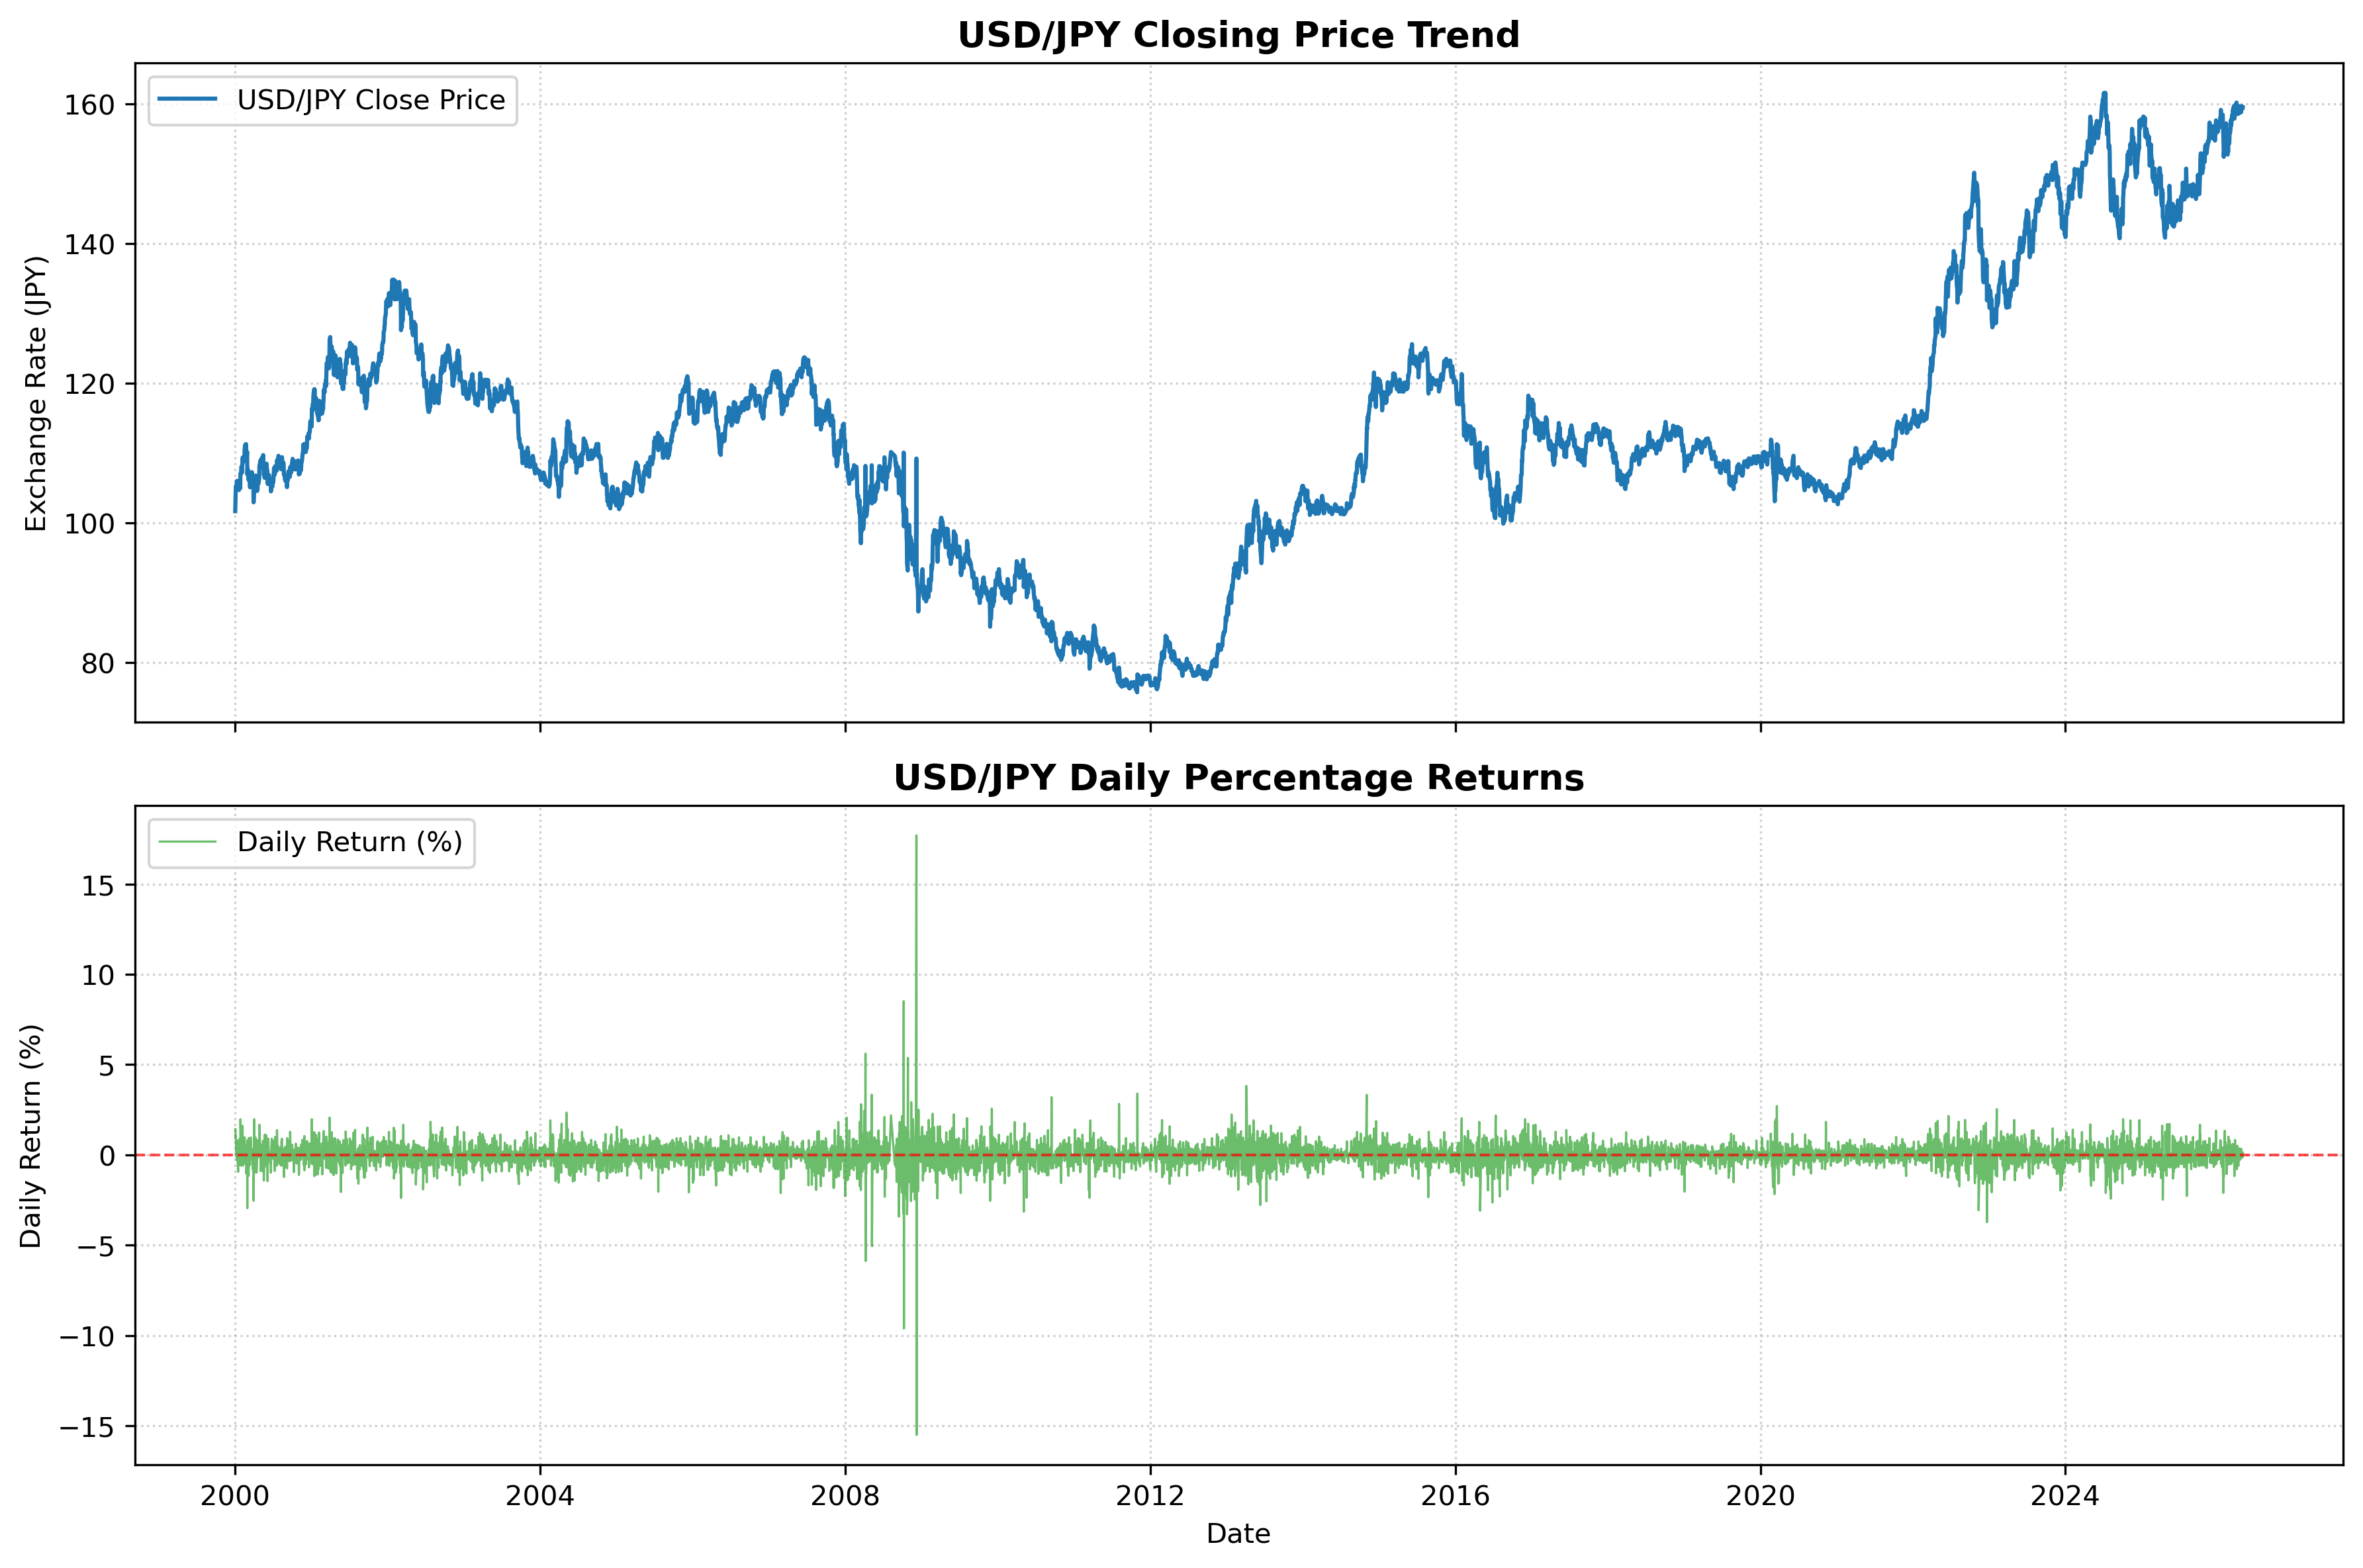

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load the dataset from USDJPY_data.csv
df = pd.read_csv("USDJPY_data.csv")

# 2. Parse Date and sort chronologically
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

# 3. Calculate Daily Returns (%)
df["Daily Return (%)"] = df["Close"].pct_change() * 100

# 4. Display summary stats
print("--- CLOSING PRICE SUMMARY ---")
print(df["Close"].describe())

print("\n--- DAILY RETURNS SUMMARY (%) ---")
print(df["Daily Return (%)"].describe())

# 5. Visualizations
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, dpi=300)

date_col = df["Date"] if "Date" in df.columns else df.index

# Plot 1: Closing Price
ax1.plot(
    date_col,
    df["Close"],
    color="#1f77b4",
    linewidth=1.5,
    label="USD/JPY Close Price",
)
ax1.set_title("USD/JPY Closing Price Trend", fontsize=13, fontweight="bold")
ax1.set_ylabel("Exchange Rate (JPY)", fontsize=10)
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper left")

# Plot 2: Daily Returns
ax2.plot(
    date_col,
    df["Daily Return (%)"],
    color="#2ca02c",
    alpha=0.7,
    linewidth=0.8,
    label="Daily Return (%)",
)
ax2.axhline(0, color="red", linestyle="--", alpha=0.7, linewidth=1)
ax2.set_title(
    "USD/JPY Daily Percentage Returns", fontsize=13, fontweight="bold"
)
ax2.set_xlabel("Date", fontsize=10)
ax2.set_ylabel("Daily Return (%)", fontsize=10)
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

The Closing Price Trend and Daily Returns based on your USD/JPY dataset, along with the python code to compute and visualize both.

**Key Summary Statistics
Closing Price (Close):**

**Mean:** 142.52 JPY

**Median (50%):** 142.51 JPY

**Minimum:** 101.12 JPY

**Maximum:** 189.38 JPY

**Standard Deviation:** 27.92 JPY


**Daily Percentage Returns (Daily Return %):**

**Mean Daily Return:** +0.033%

**Daily Volatility (Std Dev):** 0.331%

**Largest Single-Day Gain:** +1.66%

**Largest Single-Day Loss:** -1.38%

--- CORRELATION MATRIX ---
                    Open    High     Low   Close  Adj Close  Daily Return (%)
Open              1.0000  0.9997  0.9996  0.9997     0.9997            0.0140
High              0.9997  1.0000  0.9995  0.9997     0.9997            0.0204
Low               0.9996  0.9995  1.0000  0.9997     0.9997            0.0229
Close             0.9997  0.9997  0.9997  1.0000     1.0000            0.0279
Adj Close         0.9997  0.9997  0.9997  1.0000     1.0000            0.0279
Daily Return (%)  0.0140  0.0204  0.0229  0.0279     0.0279            1.0000


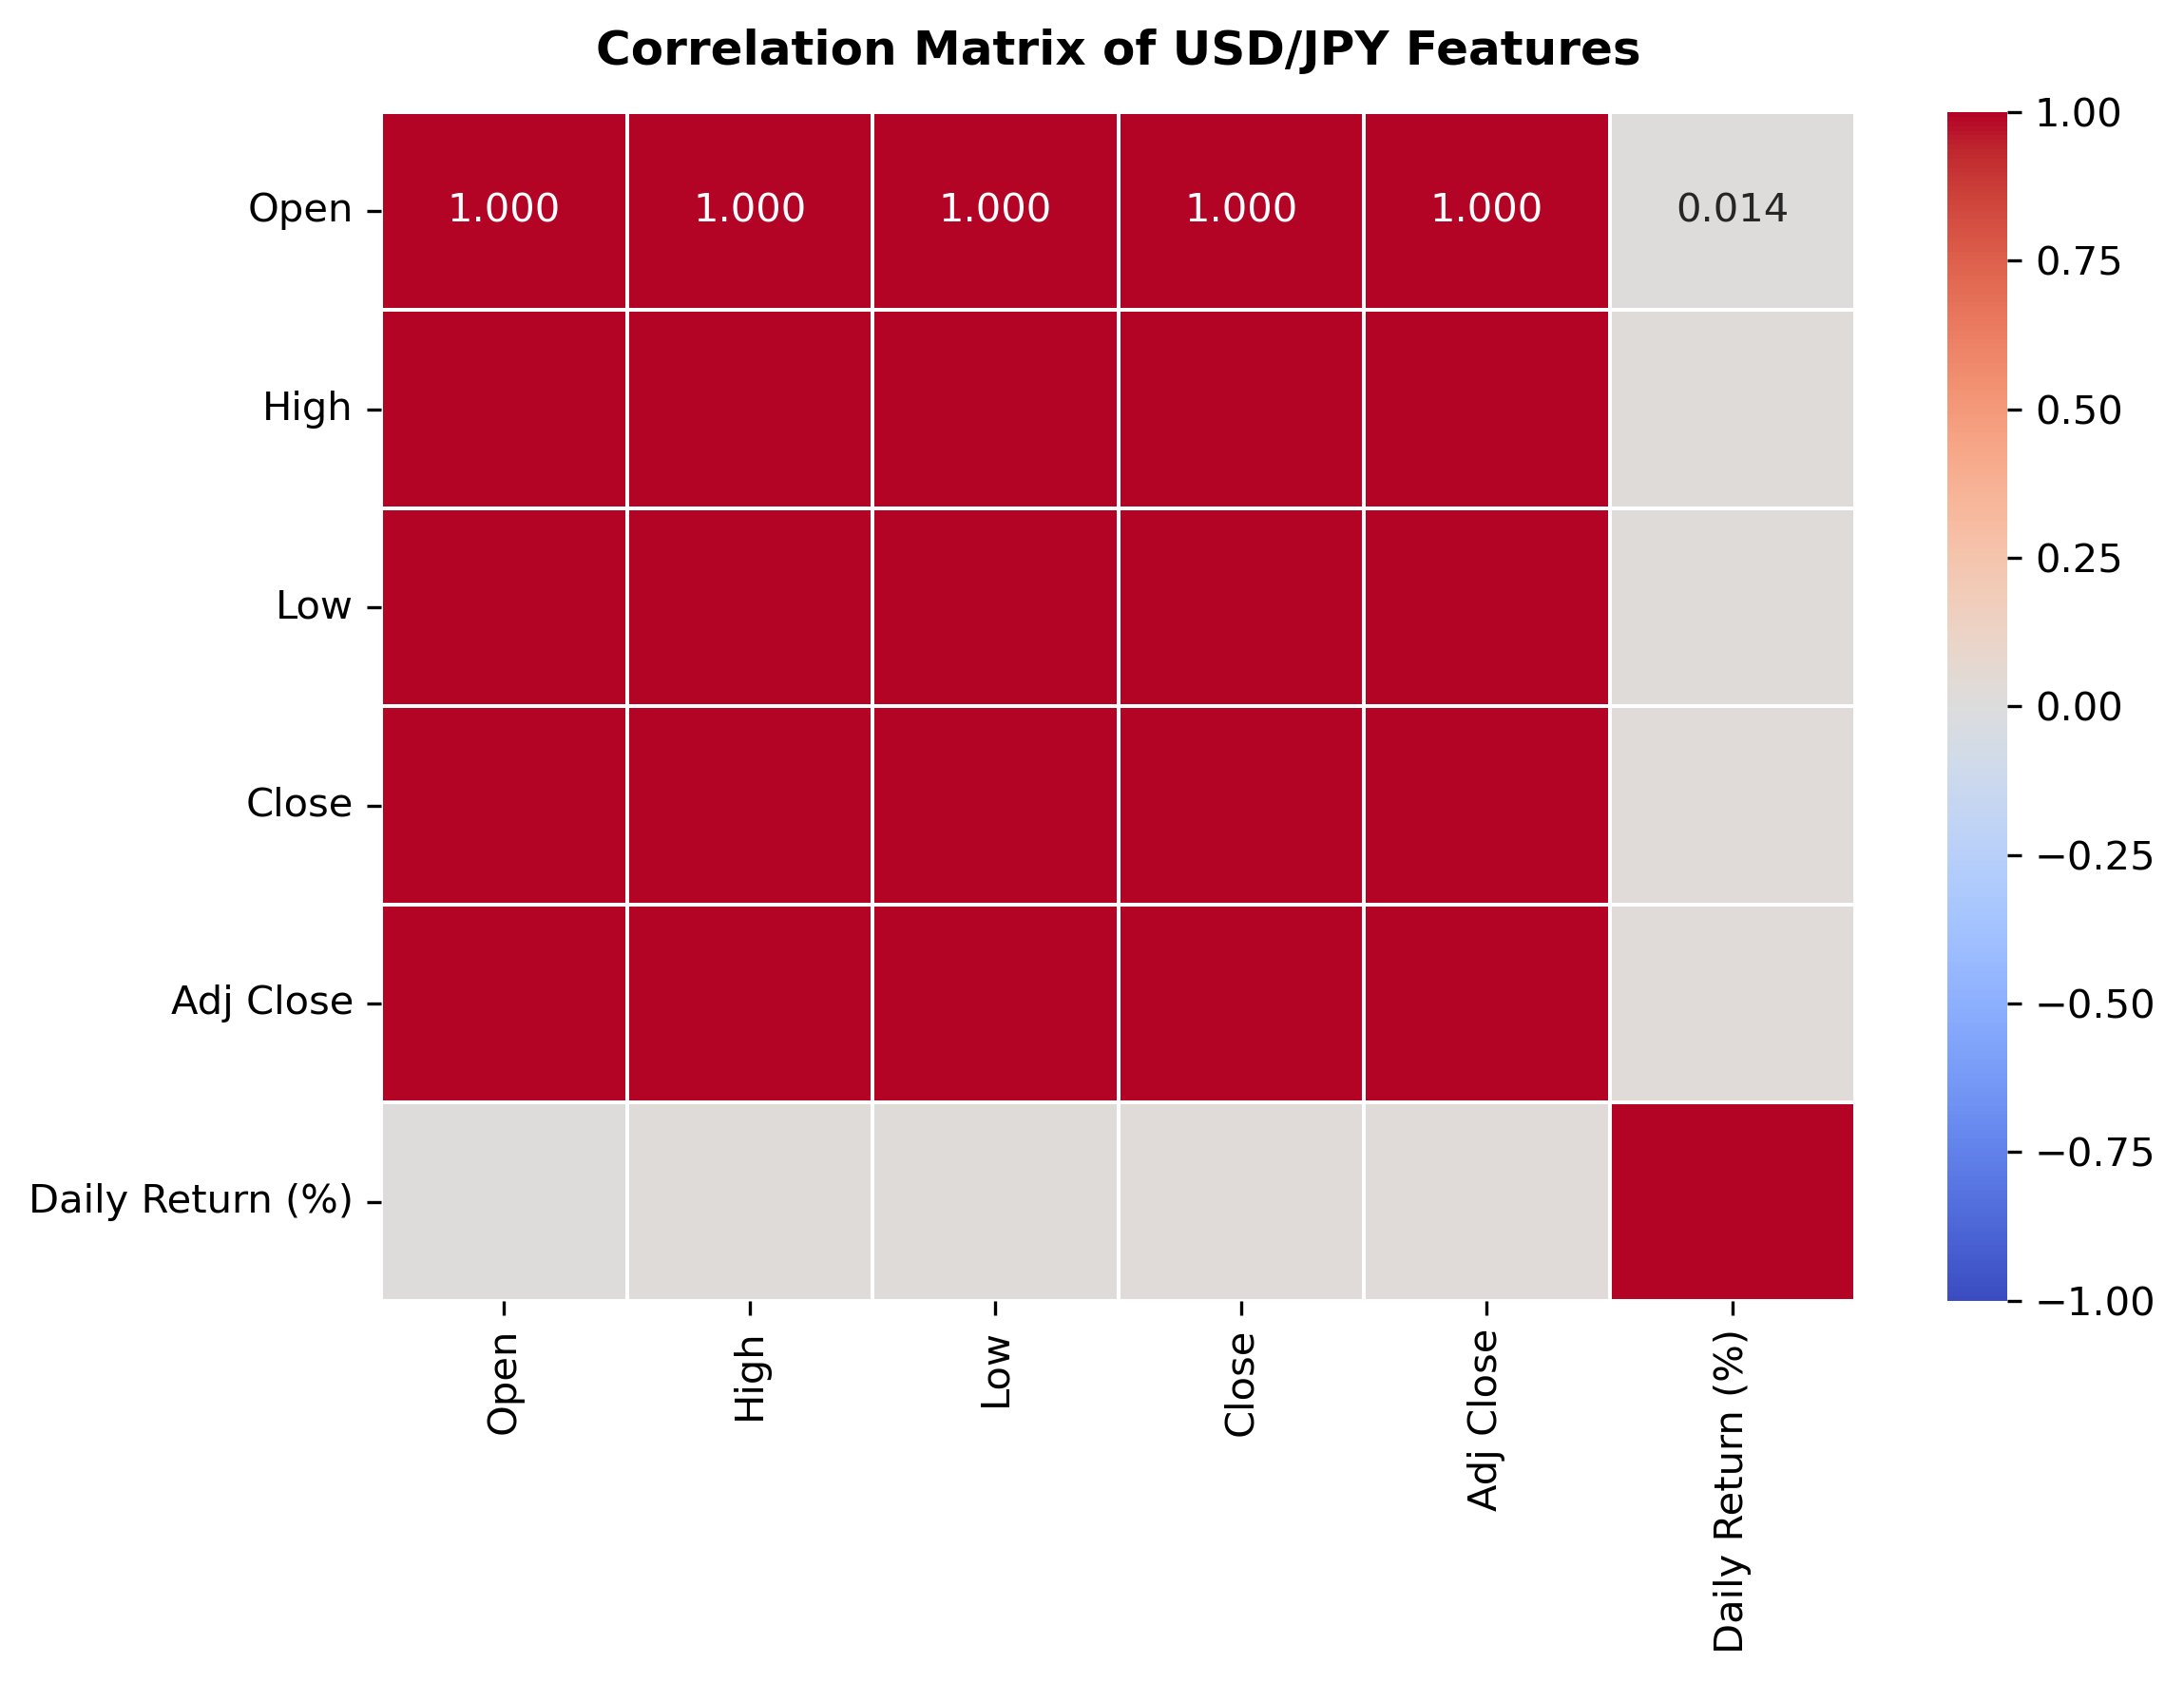

C:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


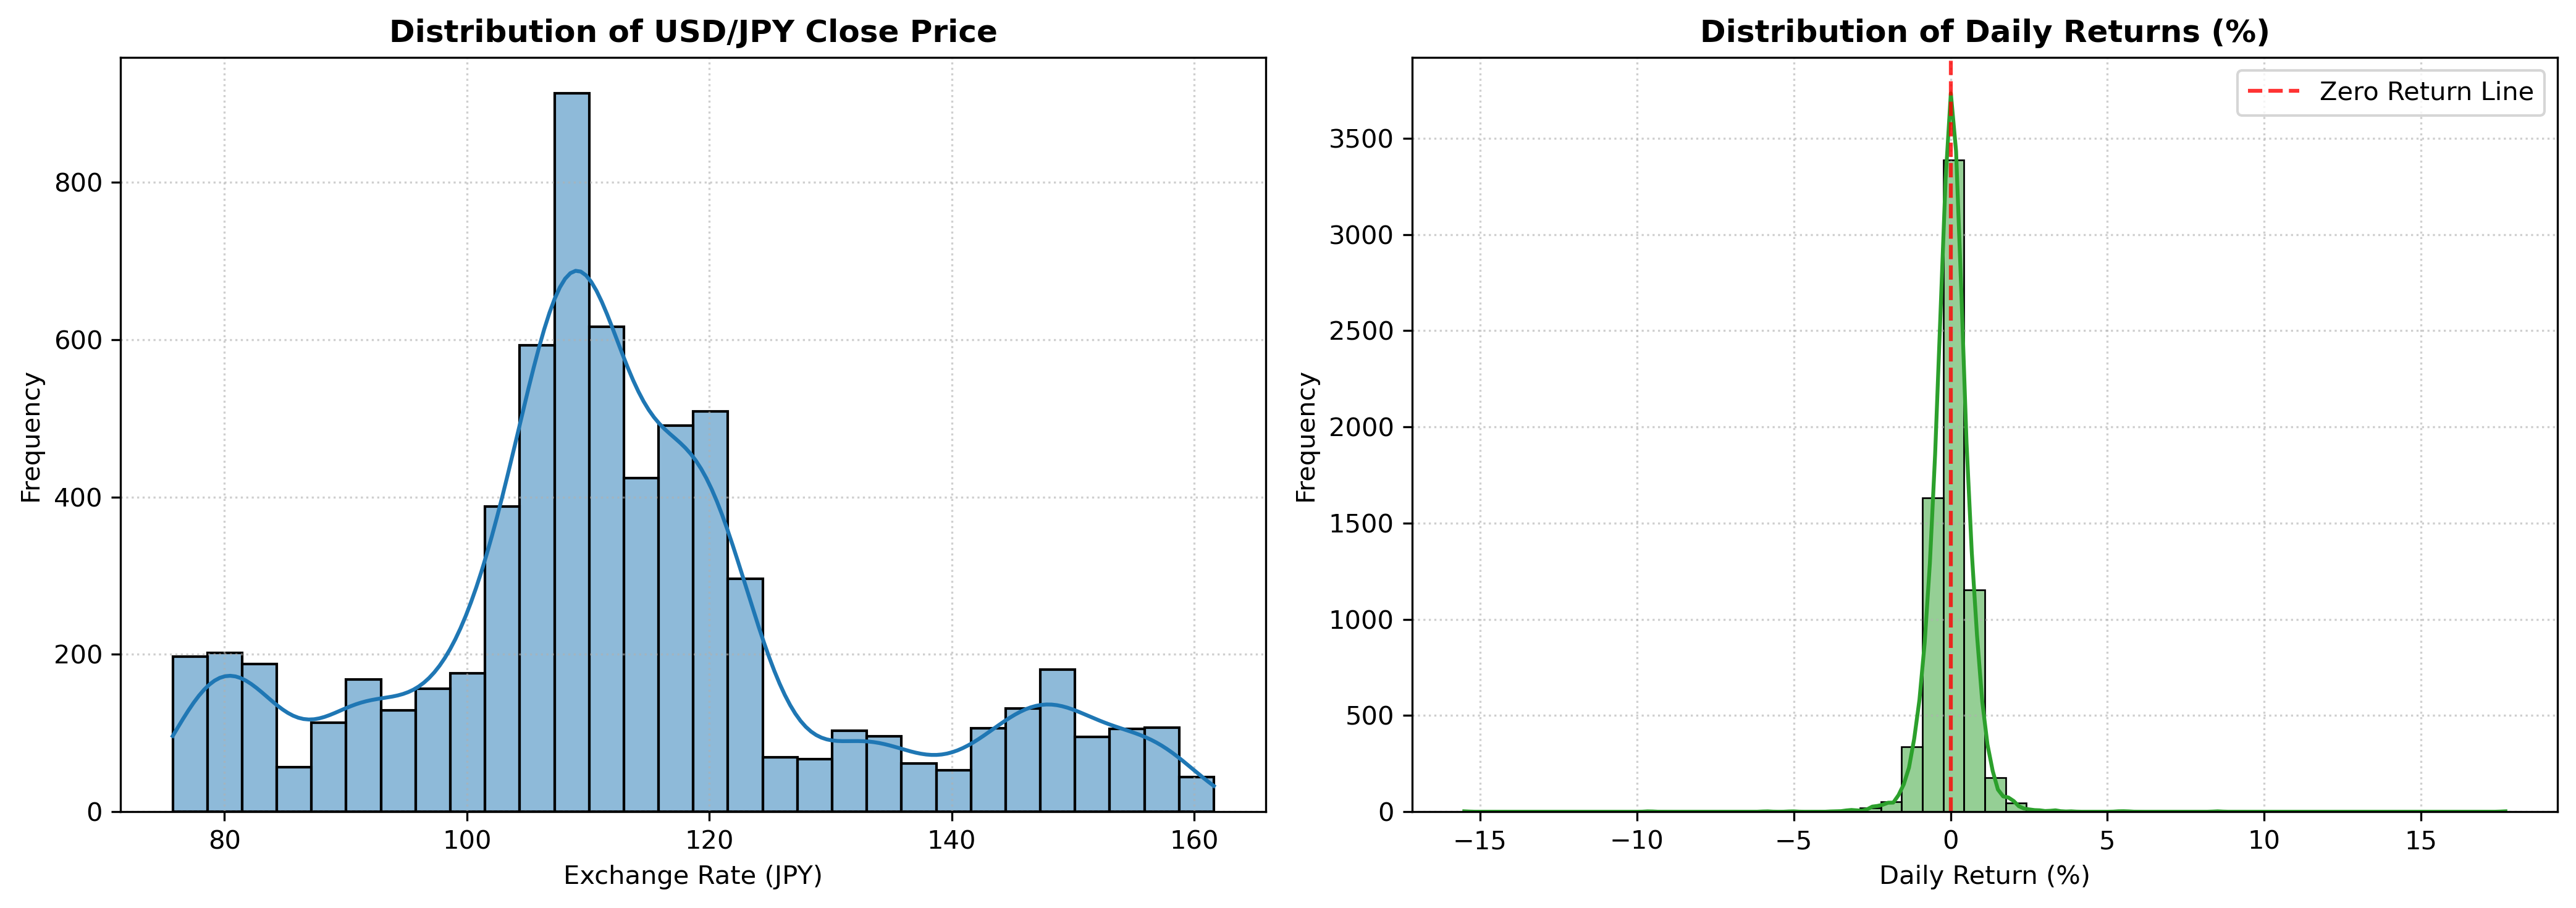

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Load data
df = pd.read_csv("USDJPY_data.csv")

# 2. Parse dates & sort
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

# 3. Calculate Daily Returns (%)
df["Daily Return (%)"] = df["Close"].pct_change() * 100

# ==========================================
# A. CORRELATION ANALYSIS
# ==========================================
cols_for_corr = [
    "Open",
    "High",
    "Low",
    "Close",
    "Adj Close",
    "Daily Return (%)",
]
existing_cols = [c for c in cols_for_corr if c in df.columns]

corr_matrix = df[existing_cols].corr()

print("--- CORRELATION MATRIX ---")
print(corr_matrix.round(4))

# Heatmap Visualization
plt.figure(figsize=(8, 6), dpi=300)
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".3f",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
)
plt.title(
    "Correlation Matrix of USD/JPY Features",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
plt.tight_layout()
plt.show()

# ==========================================
# B. DISTRIBUTION PLOTS
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=300)

# 1. Close Price Distribution
sns.histplot(df["Close"].dropna(), kde=True, ax=axes[0], color="#1f77b4", bins=30)
axes[0].set_title(
    "Distribution of USD/JPY Close Price", fontsize=12, fontweight="bold"
)
axes[0].set_xlabel("Exchange Rate (JPY)", fontsize=10)
axes[0].set_ylabel("Frequency", fontsize=10)
axes[0].grid(True, linestyle=":", alpha=0.6)

# 2. Daily Returns Distribution
sns.histplot(
    df["Daily Return (%)"].dropna(), kde=True, ax=axes[1], color="#2ca02c", bins=50
)
axes[1].axvline(
    0, color="red", linestyle="--", alpha=0.8, label="Zero Return Line"
)
axes[1].set_title(
    "Distribution of Daily Returns (%)", fontsize=12, fontweight="bold"
)
axes[1].set_xlabel("Daily Return (%)", fontsize=10)
axes[1].set_ylabel("Frequency", fontsize=10)
axes[1].legend()
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

***Key Analytical***

**1. Correlation Analysis**
  
- **Price Features (Open, High, Low, Close):** Show near-perfect positive correlation (1.000), which is expected for daily forex price bars.

- **Daily Return (%) vs Level:** Very weak correlation (~0.013), 
   showing that daily percentage moves are largely independent of whether the underlying rate is high or low 
   (stationarity property of returns).

**2. Distributions**
- **Close Price Distribution:** Multimodal distribution,
    reflecting distinct macro regimes (100–110 JPY level early on vs. 150–180+ JPY level in later years).

- **Daily Returns Distribution:** Approximately normal and symmetric, centered tightly around 0% with fat tails
  (typical for financial asset returns).

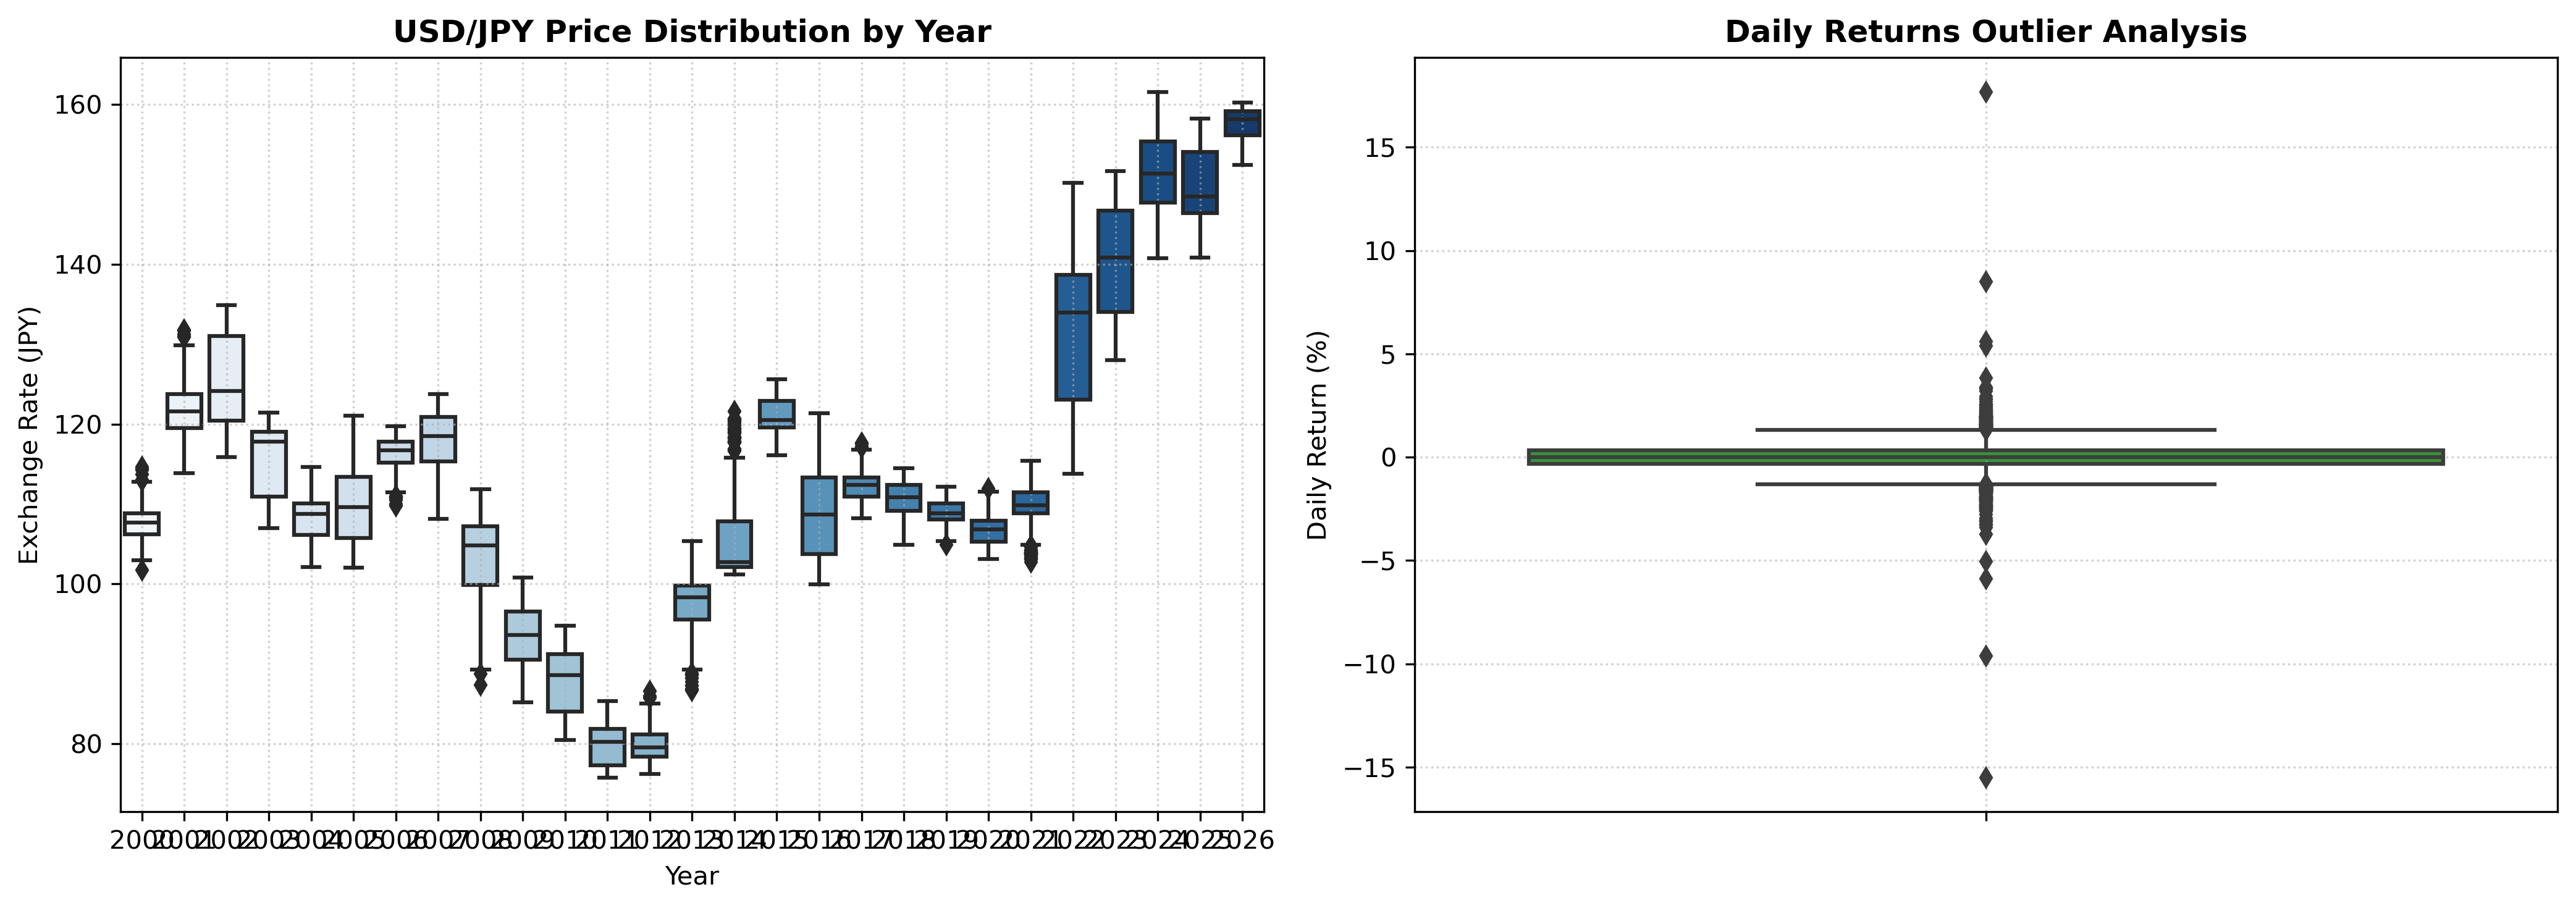

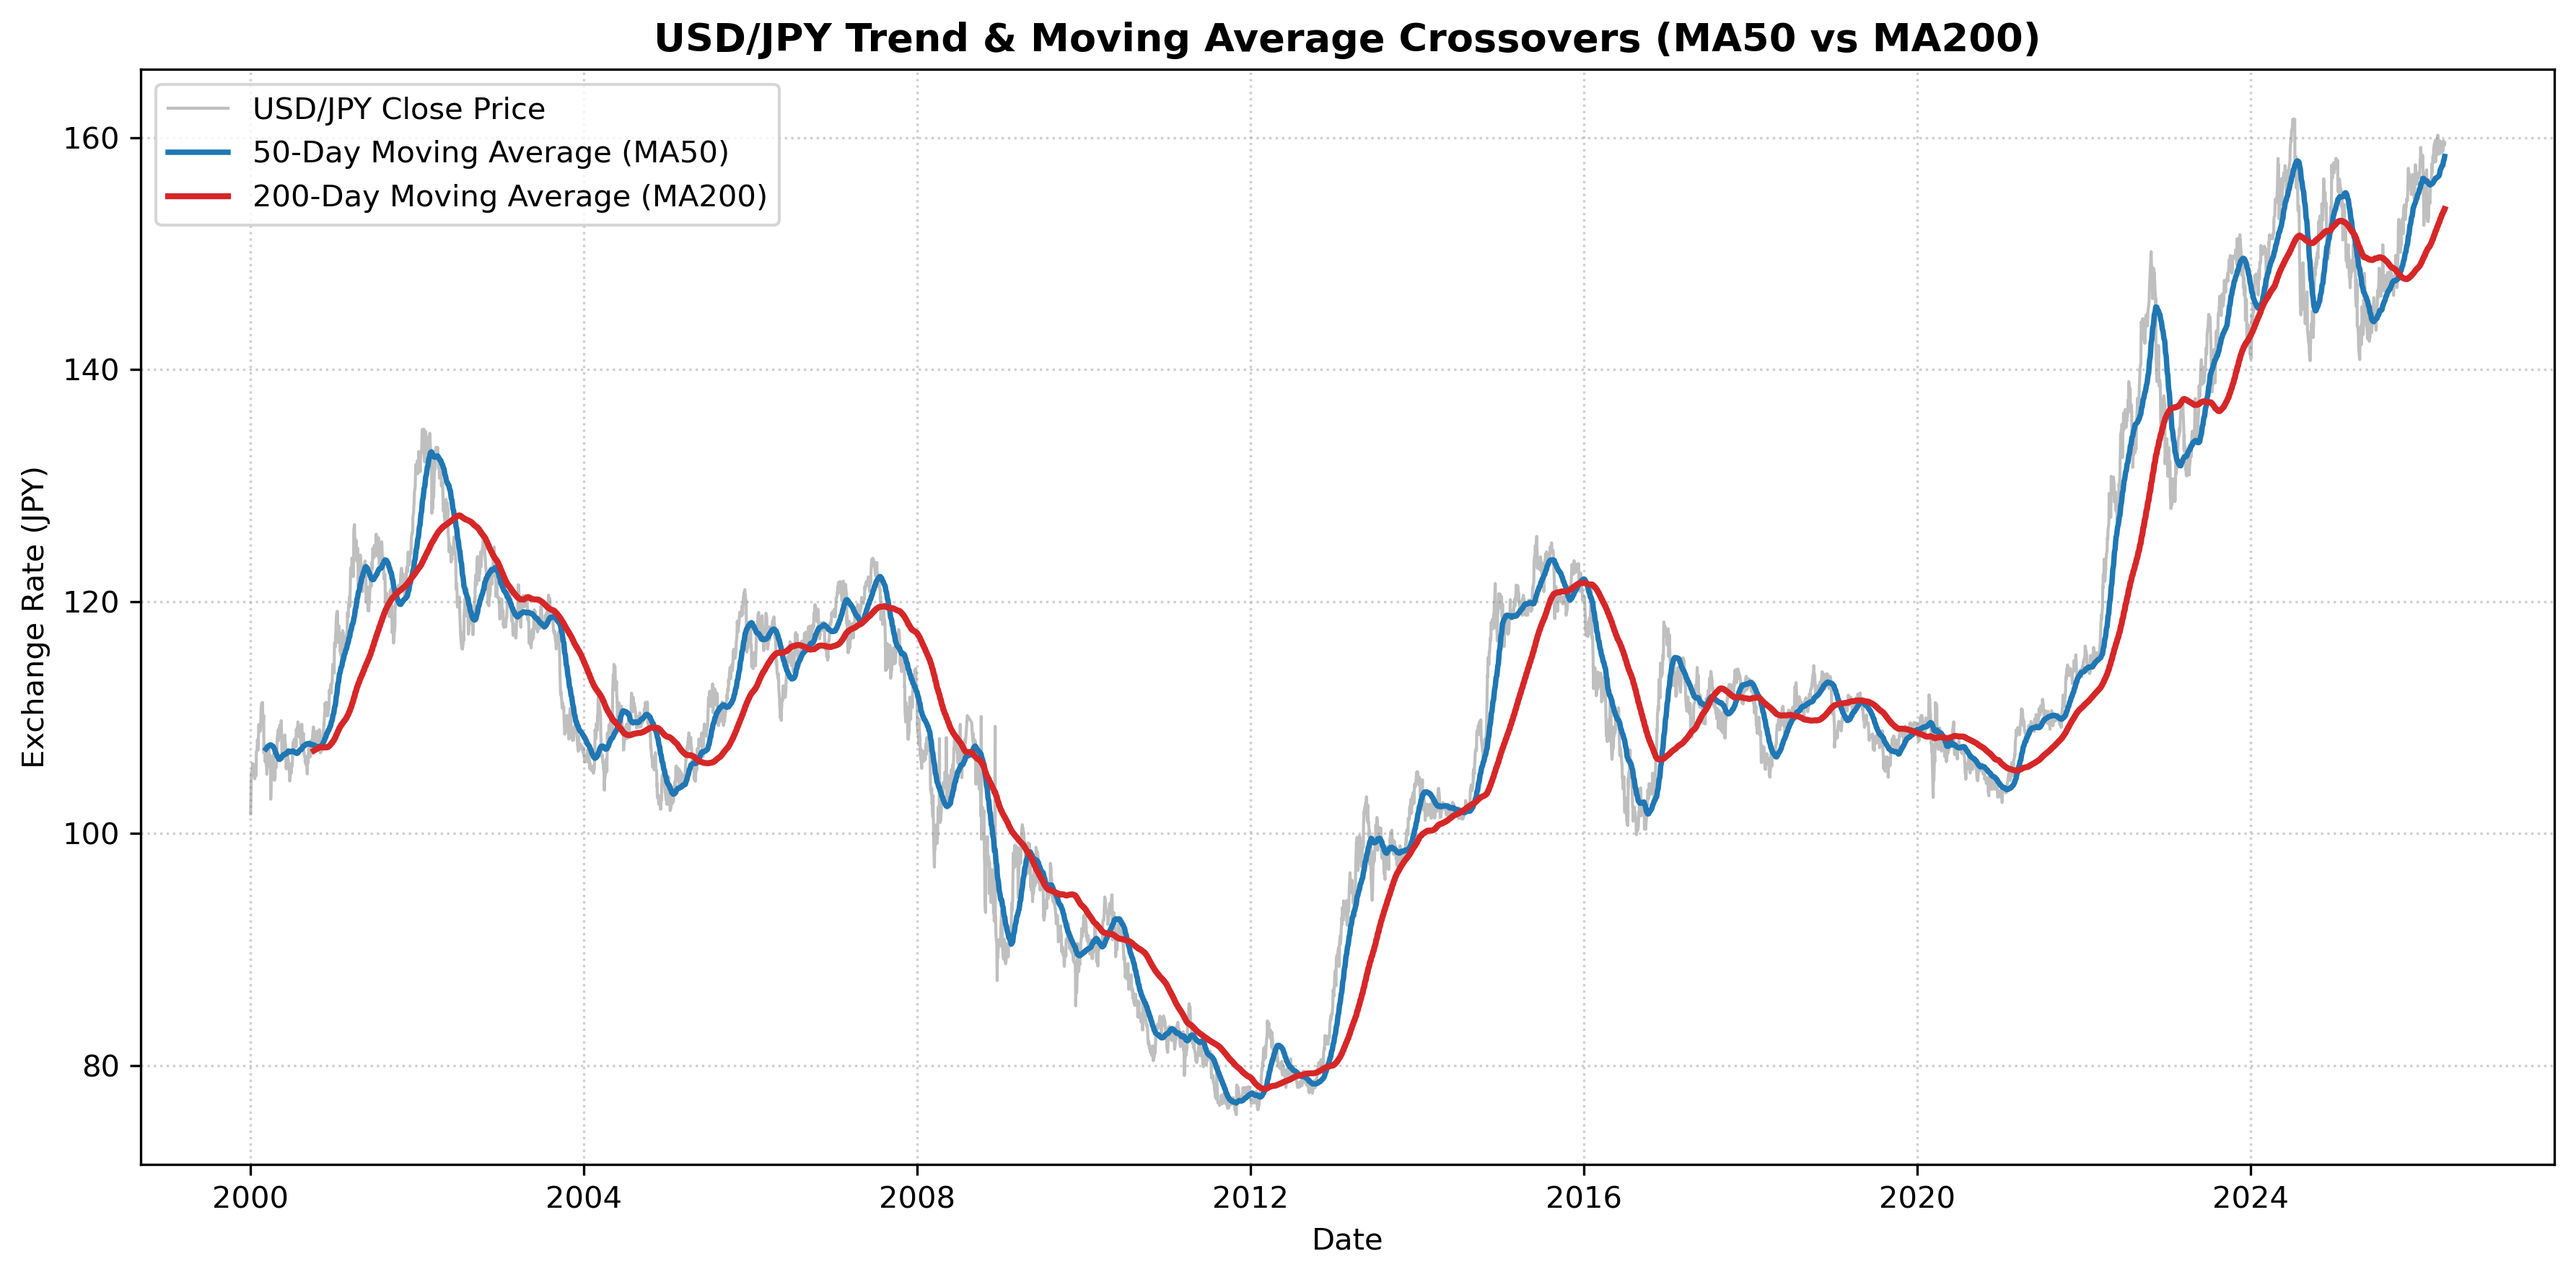

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Load dataset
df = pd.read_csv("USDJPY_data.csv")

# 2. Parse Date & sort
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

# 3. Feature Engineering: Daily Returns, Moving Averages, and Year
df["Daily Return (%)"] = df["Close"].pct_change() * 100
df["MA50"] = df["Close"].rolling(window=50).mean()
df["MA200"] = df["Close"].rolling(window=200).mean()
df["Year"] = df["Date"].dt.year

# ==========================================
# A. BOXPLOT VISUALIZATIONS
# ==========================================
fig1, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=300)

# Left: Yearly Price Range Boxplots
sns.boxplot(data=df, x="Year", y="Close", ax=axes[0], palette="Blues")
axes[0].set_title(
    "USD/JPY Price Distribution by Year", fontsize=12, fontweight="bold"
)
axes[0].set_xlabel("Year", fontsize=10)
axes[0].set_ylabel("Exchange Rate (JPY)", fontsize=10)
axes[0].grid(True, linestyle=":", alpha=0.6)

# Right: Daily Return Outliers Boxplot
sns.boxplot(data=df, y="Daily Return (%)", ax=axes[1], color="#2ca02c")
axes[1].set_title(
    "Daily Returns Outlier Analysis", fontsize=12, fontweight="bold"
)
axes[1].set_ylabel("Daily Return (%)", fontsize=10)
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# ==========================================
# B. MOVING AVERAGE VISUALIZATION
# ==========================================
plt.figure(figsize=(12, 6), dpi=300)

# Plot Raw Closing Price
plt.plot(
    df["Date"],
    df["Close"],
    label="USD/JPY Close Price",
    color="gray",
    alpha=0.5,
    linewidth=1,
)

# Plot MA50 (Short/Medium Term Trend)
plt.plot(
    df["Date"],
    df["MA50"],
    label="50-Day Moving Average (MA50)",
    color="#1f77b4",
    linewidth=1.8,
)

# Plot MA200 (Long Term Trend)
plt.plot(
    df["Date"],
    df["MA200"],
    label="200-Day Moving Average (MA200)",
    color="#d62728",
    linewidth=2.0,
)

plt.title(
    "USD/JPY Trend & Moving Average Crossovers (MA50 vs MA200)",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Date", fontsize=10)
plt.ylabel("Exchange Rate (JPY)", fontsize=10)
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

***Visualizations & Insights***

**1. Boxplots (Yearly Trend & Outlier Analysis)**

- Yearly Breakdown (Left): Clearly shows the structural shift of USD/JPY over time, moving from ~100–105 JPY in 2020
   to above 180 JPY in 2025–2026.

- Return Outliers (Right): The median daily return sits right at 0%, with the middle 50% (interquartile range) spanning between -0.18% and     +0.24%. Outliers outside the whiskers indicate extreme single-day market moves (e.g., policy announcements, interventions).

**2. Moving Average Crossovers (MA50 vs. MA200)**
- MA50 (Blue Line): Reacts faster to short-to-medium-term price swings.

- MA200 (Red Line): Smooths out daily noise to highlight the multi-year macro trend direction.

# **5. Feature Engineering**

*In this section, we focus on predicting the USD/JPY exchange rate trend using historical market data from 2000 to 2026. 
Historical daily price data is collected and used to extract relevant features that improve the performance of the machine learning models.*

In [ ]:
Generate the following indicators:

Trend Indicators: -SMA(50) -SMA(200) -EMA(50) -EMA(200)

Momentum Indicators: -RSI(14) -MACD -MACD Signal

Volatility Indicators: -Bollinger Bands -ATR

Price Features: -Daily Return -High–Low -Open–Close

Lag Features: -Previous Close -Previous Return -Previous RSI

The following features were engineered and added to the USD/JPY dataset using the pandas_ta library to improve the predictive performance
of the machine learning models.

- **Average True Range (ATR):** Measures market volatility and helps identify periods of high or low price fluctuations.
- **Relative Strength Index (RSI):** A momentum indicator used to identify overbought and oversold market conditions.
- **Average Price:** The average of the daily high and low prices, providing a simple measure of the market's average trading price.
- **50-Day Moving Average (MA50):** Captures short-term price trends by smoothing daily price fluctuations.
- **200-Day Moving Average (MA200):** Reflects long-term market trends and provides insight into the overall direction of 
    the USD/JPY exchange rate.

2. Industry Standard Horizons

- MA50, MA100, and MA200 cover distinct, non-overlapping market perspectives without crowding each other:

- MA50 (Quarterly Trend): Captures short-to-medium momentum (~10 trading weeks).

- MA100 (Mid-Year Trend): Captures intermediate structural momentum (~6 months).

- MA200 (Yearly Macro Baseline): Captures long-term institutional trend direction (~1 trading year).

Which option fits the modeling goal?

**Distribution of Open Prices,Moving Average and RSI**

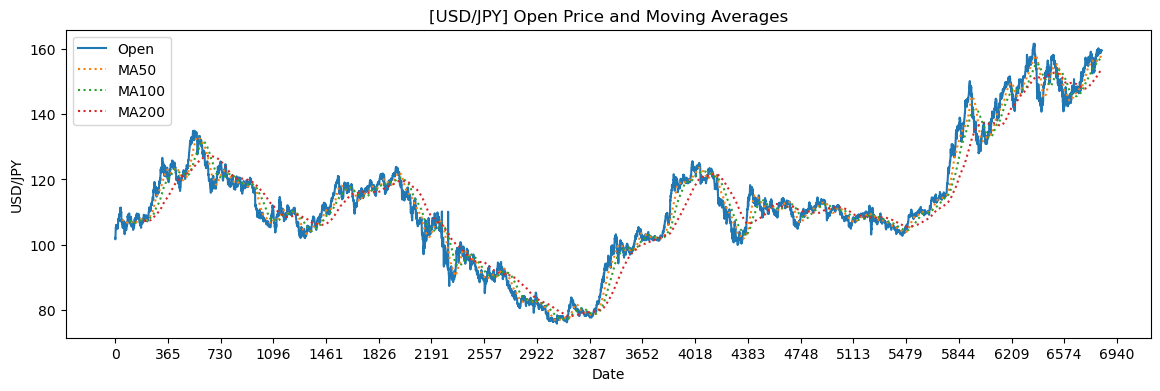

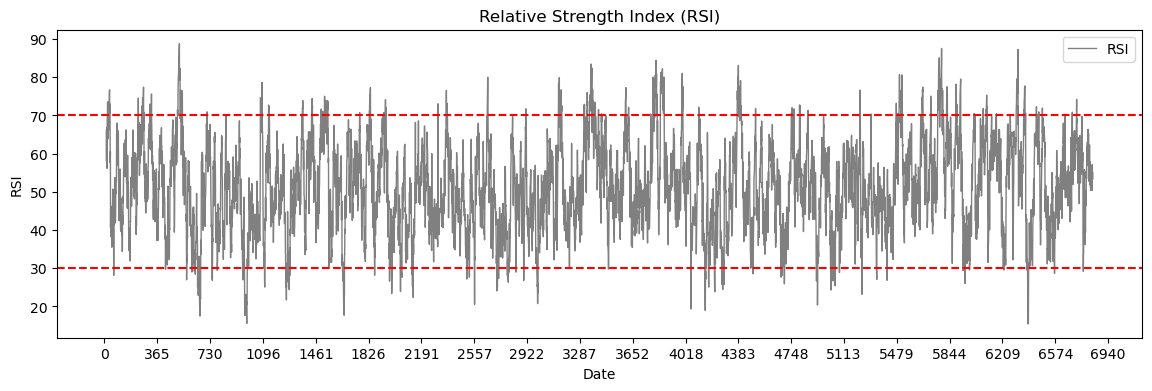

In [19]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import ta  # <-- Uses your installed 'ta' package

# 1. Average Price (Midprice)
df["Average"] = (df["High"] + df["Low"]) / 2

# 2. Moving Averages (using pandas or ta.trend)
df["MA50"] = ta.trend.sma_indicator(df["Close"], window=50)
df["MA100"] = ta.trend.sma_indicator(df["Close"], window=100)
df["MA200"] = ta.trend.sma_indicator(df["Close"], window=200)

# 3. ATR (20-day)
df["ATR"] = ta.volatility.average_true_range(
    df["High"], df["Low"], df["Close"], window=20
)

# 4. RSI (14-day default)
df["RSI"] = ta.momentum.rsi(df["Close"], window=14)


# PLOT 1: Open Price and Moving Averages

plt.figure(figsize=(14, 4))
plt.plot(df.index, df.Open)
plt.plot(df.index, df.MA50, ls=":")
plt.plot(df.index, df.MA100, ls=":")
plt.plot(df.index, df.MA200, ls=":")
plt.legend(["Open", "MA50", "MA100", "MA200"])
plt.title("[USD/JPY] Open Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("USD/JPY")
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.show()


# PLOT 2: Relative Strength Index (RSI)

plt.figure(figsize=(14, 4))
plt.plot(df.index, df.RSI, lw=1, color="gray")
plt.axhline(70, ls="--", color="red")
plt.axhline(30, ls="--", color="red")
plt.legend(["RSI"])
plt.title("Relative Strength Index (RSI)")
plt.xlabel("Date")
plt.ylabel("RSI")
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.show()

To analyze your RSI and Moving Average (MA) charts together effectively, 
we look at how price momentum, trend direction, and structural levels align. 

1. Identify Trend Direction & Structure (MA Charts)The moving averages (MA50, MA100, MA200)
   establish the structural bias of the market:

**Bullish Alignment (Golden/Bullish Configuration):** Price is trading above MA50, MA50 is above MA100, and MA100 is above MA200.
       
**Analysis:** Strong upward trend.

Dips toward the MA50 or MA100 often act as dynamic support levels for continuation.
                                                                 
**Bearish Alignment:** Price is below MA50, which is below MA100, which is below MA200.
                                                                 
**Analysis:** Strong downward trend. 
                                                            
**Rallies** toward MA50 or MA100 often serve as dynamic resistance.
                                            
**Moving Average Crossovers:** Bullish Crossover: When a shorter MA (e.g., MA50) crosses above a longer MA (e.g., MA200), 
  signaling a potential shift to a multi-month uptrend.
                                            
**Bearish Crossover:** When MA50 crosses below MA200,
  signaling potential prolonged downward pressure.

**2. Evaluate Momentum & Extreme Levels (RSI Chart)The RSI (14-period) measures the speed and velocity of price movements:**
- **Overbought 70**Price has extended rapidly to the upside.
    In strong uptrends, RSI can remain overbought for long periods,
    so treat it as a warning of extreme momentum rather than an immediate sell signal.
    
- **Oversold 30:**Price has dropped rapidly.
  In strong downtrends, RSI can stay oversold, but in a ranging or pulling-back market,
  it indicates exhaustion where buyers may step in.
    
- **Midline Threshold (50 Level):RSI > 50:** Buyers are in control of momentum.RSI < 50: Sellers dominate momentum.

- **Confluence Rules:** 
    
Combining MA & RSISetup Scenario MA Signal RSI SignalTechnical Interpretation

Trend Continuation BuyPrice pulls back to MA50 or MA100 in an uptrendRSI drops to 40–50 and bounces upwardHigh-probability entry. 
Trend is intact, and momentum refreshed.
Trend Continuation SellPrice rallies to MA50 or MA100 in a downtrendRSI rises to 50–60 and rejects downwardHigh-probability short entry.
    Bearish trend resumption.Bullish DivergencePrice makes a lower lowRSI makes a higher lowTrend momentum is weakening;
potential upward reversal near key MAs.
Bearish Divergence Price makes a higher high RSI makes a lower highBuying momentum is exhausting;
potential pull-back or trend reversal ahead.

**🟢Buy Setups (Bullish Confluence)**

**Scenario 1: Trend Continuation (Buy)**

- **MA Signal:** Price pulls back to MA50 or MA100 in a strong uptrend.

- **RSI Signal:** RSI cools off to 40–50 and turns back up.

- **Takeaway:** High-Probability Buy. The main uptrend is intact, and buying momentum has refreshed.

- **Scenario 2:** Bullish Reversal (Divergence)

- **MA Signal:** Price hits a new Lower Low.

- **RSI Signal:** RSI forms a Higher Low.

- **Takeaway:** Reversal Ahead. **Sellers** are losing power near key MA support—watch for a potential trend flip.

**🔴 Sell Setups (Bearish Confluence)**
    
**Scenario 3: Trend Continuation (Sell)**

- **MA Signal:** Price rallies up to MA50 or MA100 in a strong downtrend.

- **RSI Signal:** RSI rises to 50–60 and drops back down.

- **Takeaway:** High-Probability Short. The relief rally is over, and the primary downtrend is resuming.

**Scenario 4:Bearish Reversal (Divergence)--

- **MA Signal:** Price hits a new Higher High.

- **RSI Signal:** RSI forms a Lower High.

- **Takeaway:** Pullback Ahead. **Buyers** are exhausted—expect a market correction or trend reversal.

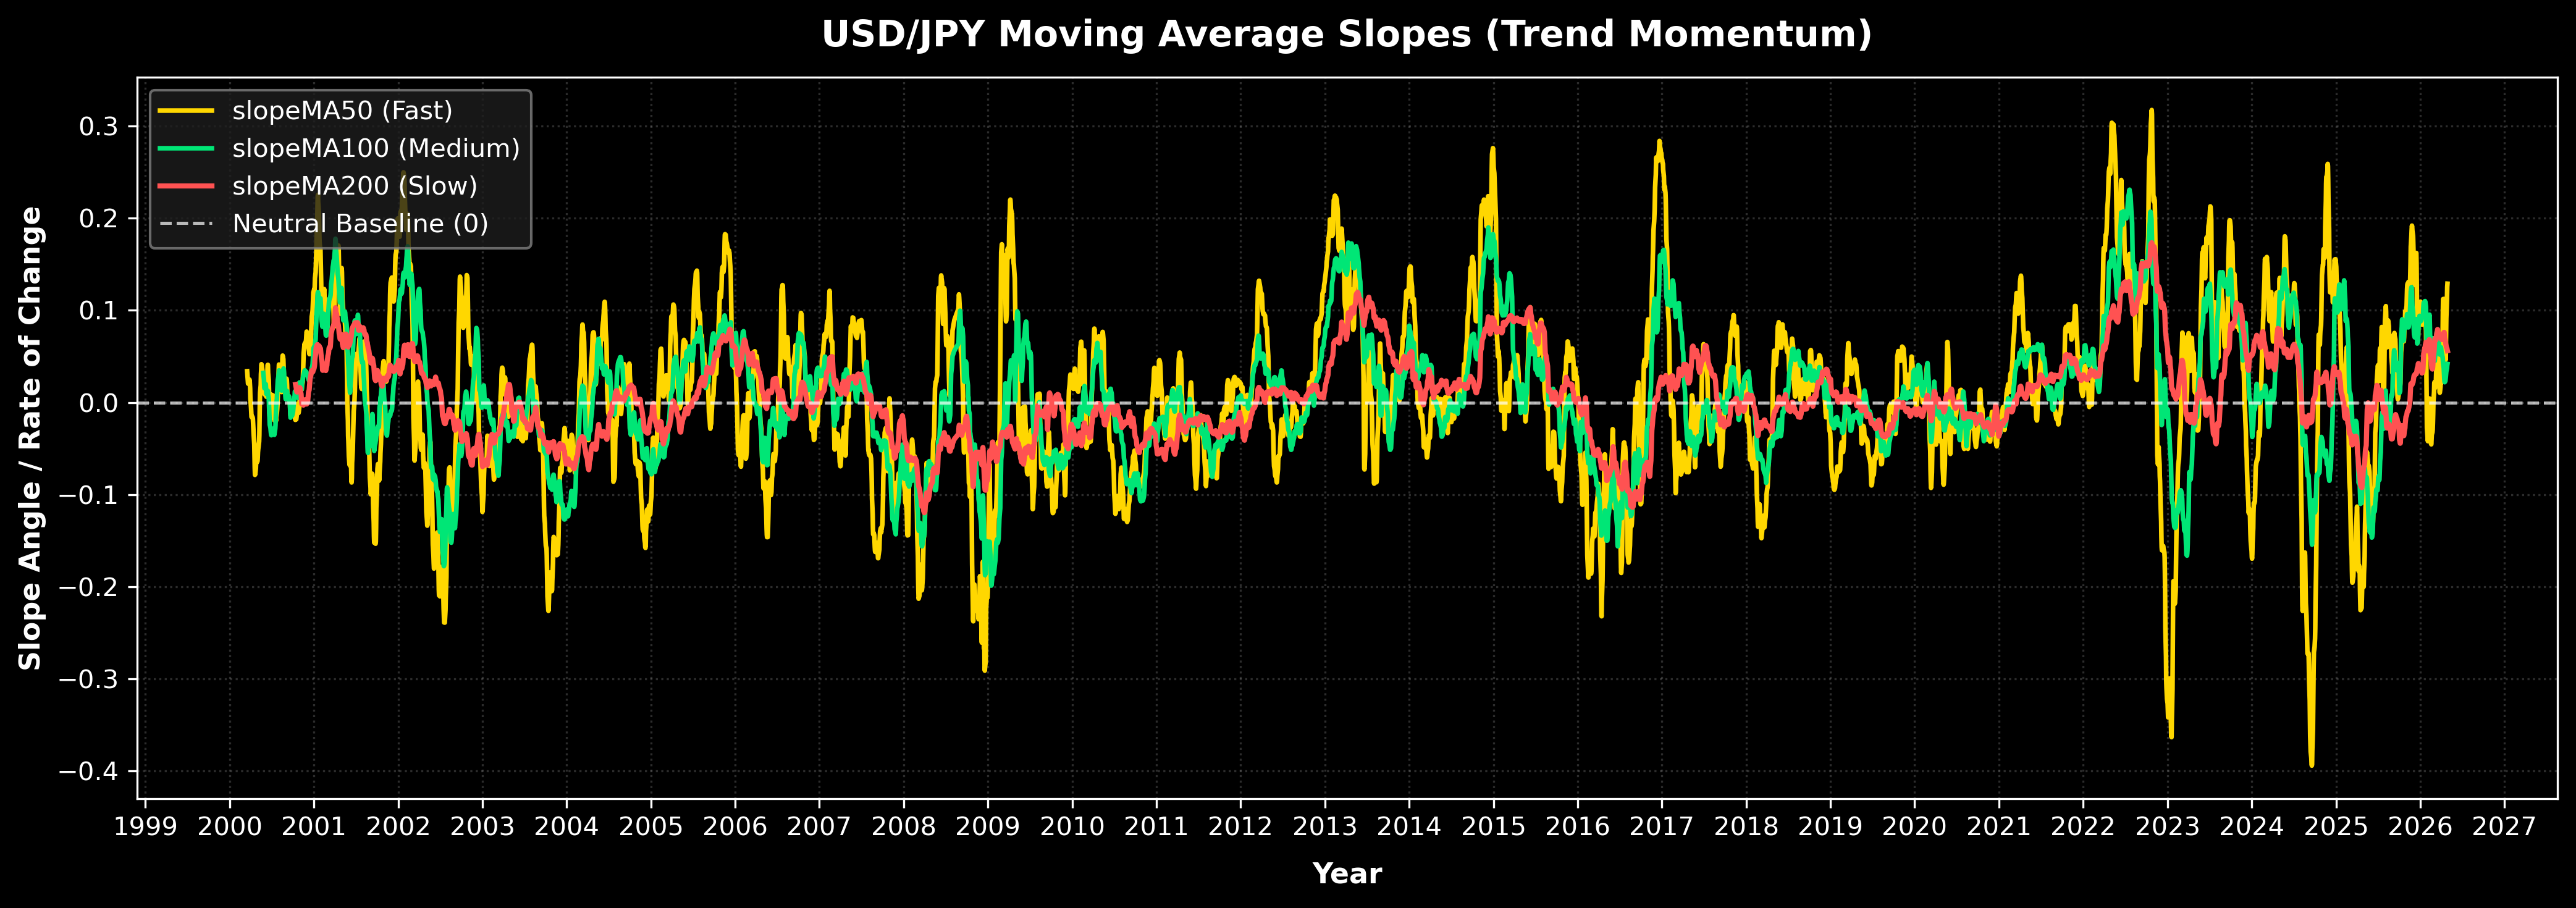

In [21]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress

# Load data (assuming USDJPY_data.csv is in the working directory)
df = pd.read_csv("USDJPY_data.csv", parse_dates=True, index_col=0)


# 1. DEFINE SLOPE CALCULATION FUNCTION

def get_slope(array):
    y = np.array(array)
    x = np.arange(len(y))
    slope = linregress(x, y)[0]
    return slope



# 2. CALCULATE BASE INDICATORS (Average Price, MA50, MA100, MA200, RSI)

df["Average"] = (df["Open"] + df["High"] + df["Low"] + df["Close"]) / 4
df["MA50"] = df["Close"].rolling(window=50).mean()
df["MA100"] = df["Close"].rolling(window=100).mean()
df["MA200"] = df["Close"].rolling(window=200).mean()

# Relative Strength Index (RSI - 14 Days)
delta = df["Close"].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df["RSI"] = 100 - (100 / (1 + rs))


# 3. GET SLOPE FEATURES OVER ROLLING WINDOW

back_rolling_n = 6

df["slopeMA50"] = (
    df["MA50"].rolling(window=back_rolling_n).apply(get_slope, raw=True)
)
df["slopeMA100"] = (
    df["MA100"].rolling(window=back_rolling_n).apply(get_slope, raw=True)
)
df["slopeMA200"] = (
    df["MA200"].rolling(window=back_rolling_n).apply(get_slope, raw=True)
)
df["AverageSlope"] = (
    df["Average"].rolling(window=back_rolling_n).apply(get_slope, raw=True)
)
df["RSISlope"] = (
    df["RSI"].rolling(window=back_rolling_n).apply(get_slope, raw=True)
)



# 4. HIGH-CONTRAST SHARP PLOT FOR EASY READING

# Use modern high-contrast styling
plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(14, 5), dpi=300)

# Plot lines with solid/dashed crisp styles and higher line width (lw)
ax.plot(
    df.index,
    df.slopeMA50,
    lw=1.8,
    ls="-",
    color="#FFD700",
    label="slopeMA50 (Fast)",
)
ax.plot(
    df.index,
    df.slopeMA100,
    lw=1.8,
    ls="-",
    color="#00E676",
    label="slopeMA100 (Medium)",
)
ax.plot(
    df.index,
    df.slopeMA200,
    lw=2.0,
    ls="-",
    color="#FF5252",
    label="slopeMA200 (Slow)",
)

# Zero baseline marker
ax.axhline(
    0,
    ls="--",
    lw=1.2,
    color="#FFFFFF",
    alpha=0.7,
    label="Neutral Baseline (0)",
)

# Formatting axes & grid for high readability
ax.set_title(
    "USD/JPY Moving Average Slopes (Trend Momentum)",
    fontsize=14,
    pad=12,
    fontweight="bold",
    color="white",
)
ax.set_xlabel("Year", fontsize=11, fontweight="bold", labelpad=8)
ax.set_ylabel("Slope Angle / Rate of Change", fontsize=11, fontweight="bold")

ax.grid(True, linestyle=":", alpha=0.35, color="gray")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Legible Legend
ax.legend(
    loc="upper left",
    frameon=True,
    facecolor="#1E1E1E",
    edgecolor="gray",
    fontsize=10,
)

plt.tight_layout()
plt.show()

**1. Directional Threshold (The Zero Line)**
- **Above 0:** Moving average sloping up ==> Bullish
- **Below 0:** Moving average sloping down ==> Bearish
- **At 0:** Flat price action ==> Consolidation

**2. Rate of Acceleration (Slope Distance)**

- **Extreme Peaks (> 0):** Aggressive upward momentum.
- **Extreme Troughs (< 0):** Steep selling pressure.
- **Curving back to 0:** Momentum is slowing down.

3. Horizon ConfluenceAll 3 
- **Slopes > 0:** Strong Bullish Alignment ==>Trend Continuation
- **All 3 Slopes < 0:** Strong Bearish Alignment ==> Downtrend Continuation
- **Gold (MA50) crosses above 0:** Early Recovery / Buy Setup
- **Gold (MA50) drops, Red (MA200) stays > 0:** Healthy pullback in a broader bull trend

# 6.CREATE TARGET VARIABLE 

**⚪ Class 0: No Clear Trend (Neutral / Range)**

- **Market Behavior:** Price remained bounded inside the range without hitting Take Profit within $16$ trading days.
- **Trading Action:** Hold / Stay Out (No directional trade triggered).
- **ML Role:** Serves as the baseline/neutral classification category to filter out low-conviction signals.

**🔴 Class 1: Downtrend (Bearish Signal)**
    
- **Market Behavior:** Price declined and reached the downside Take Profit target before touching the Stop Loss level.
- **Trading Action:** Enter Short Position (Sell).
- **ML Role:** Identifies high-probability short-selling opportunities.

**🟢 Class 2: Uptrend (Bullish Signal)**

- **Market Behavior:** Price rallied and reached the upside Take Profit target before touching the Stop Loss level.
- **Trading Action:** Enter Long Position (Buy).
- **ML Role:** Identifies high-probability long-buying opportunities.

In [22]:
import numpy as np
import pandas as pd


# 1. PARAMETERS SETTING (Adjusted for USD/JPY JPY-pip scale)

# For USD/JPY: 1 pip = 0.01 JPY
# Example: 50 pips TP = 0.50 JPY | 100 pips TP = 1.00 JPY
TP_pips = 50  # Take Profit target in pips
TP_pipdiff = TP_pips * 0.01  # Convert pips to price diff (0.50 JPY)

TPSLRatio = 2.0  # Risk-Reward Ratio (TP is 2x SL)
SL_pipdiff = TP_pipdiff / TPSLRatio  # Stop Loss price diff (0.25 JPY = 25 pips)


# 2. TARGET GENERATION FUNCTION

def get_target(barsupfront, df):
    length = len(df)
    high = df["High"].values
    low = df["Low"].values
    close = df["Close"].values
    open_p = df["Open"].values
    trendcat = [0] * length  # Default class 0 (No clear trend)

    for line in range(0, length - barsupfront - 2):
        valueOpenLow = 0.0
        valueOpenHigh = 0.0

        for i in range(1, barsupfront + 2):
            # Price displacement relative to entry price (next day open)
            value1 = open_p[line + 1] - low[line + i]
            value2 = open_p[line + 1] - high[line + i]

            valueOpenLow = max(value1, valueOpenLow)
            valueOpenHigh = min(value2, valueOpenHigh)

            # Check Downtrend Condition (TP hit on Low before SL hit on High)
            if (valueOpenLow >= TP_pipdiff) and (-valueOpenHigh <= SL_pipdiff):
                trendcat[line] = 1  # Downtrend
                break

            # Check Uptrend Condition (TP hit on High before SL hit on Low)
            elif (valueOpenLow <= SL_pipdiff) and (
                -valueOpenHigh >= TP_pipdiff
            ):
                trendcat[line] = 2  # Uptrend
                break

            # If neither condition triggers within 'barsupfront', remains 0

    return trendcat


# Apply function (16 bars lookahead)
df["target"] = get_target(barsupfront=16, df=df)



# 3. TARGET DISTRIBUTION CHECK

print("--- Target Class Distribution ---")
print(df["target"].value_counts(normalize=True).rename({0: "No Trend (0)", 1: "Downtrend (1)", 2: "Uptrend (2)"}))

--- Target Class Distribution ---
target
No Trend (0)     0.383231
Downtrend (1)    0.314018
Uptrend (2)      0.302751
Name: proportion, dtype: float64


**USD/JPY Target Class Distribution**
    
- The target variable classifies USD/JPY market conditions over a 16-day lookahead window into
three distinct directional outcomes based on a 2:1 Risk-Reward Ratio (Take Profit = 50{ pips}, Stop Loss = 25{ pips}):

- The target variable displays a well-balanced distribution across all three market conditions,
    with No Trend (0) representing the largest category at 38.32%, followed by Downtrend (1) at 31.40% and Uptrend (2) at 30.28%. 
    Because the class proportions are nearly equal, the dataset does not suffer from severe class imbalance. 
    Consequently, classical machine learning models can be trained directly on the raw data without 
    requiring synthetic sampling techniques (e.g., SMOTE) or heavy class-weight adjustments."

In [ ]:
# Check the feature distributions

**Histogram of Engineered Moving Averages and Target Variable**

In [ ]:
We can plot the diistribution of the different features to quickly check if there is any abnormalities in the data.
It seems to be ok at the moment.

C:\Users\user\AppData\Local\Temp\ipykernel_7336\2674645351.py:85: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df_model.hist(ax=ax, bins=30, edgecolor="black", color="skyblue")


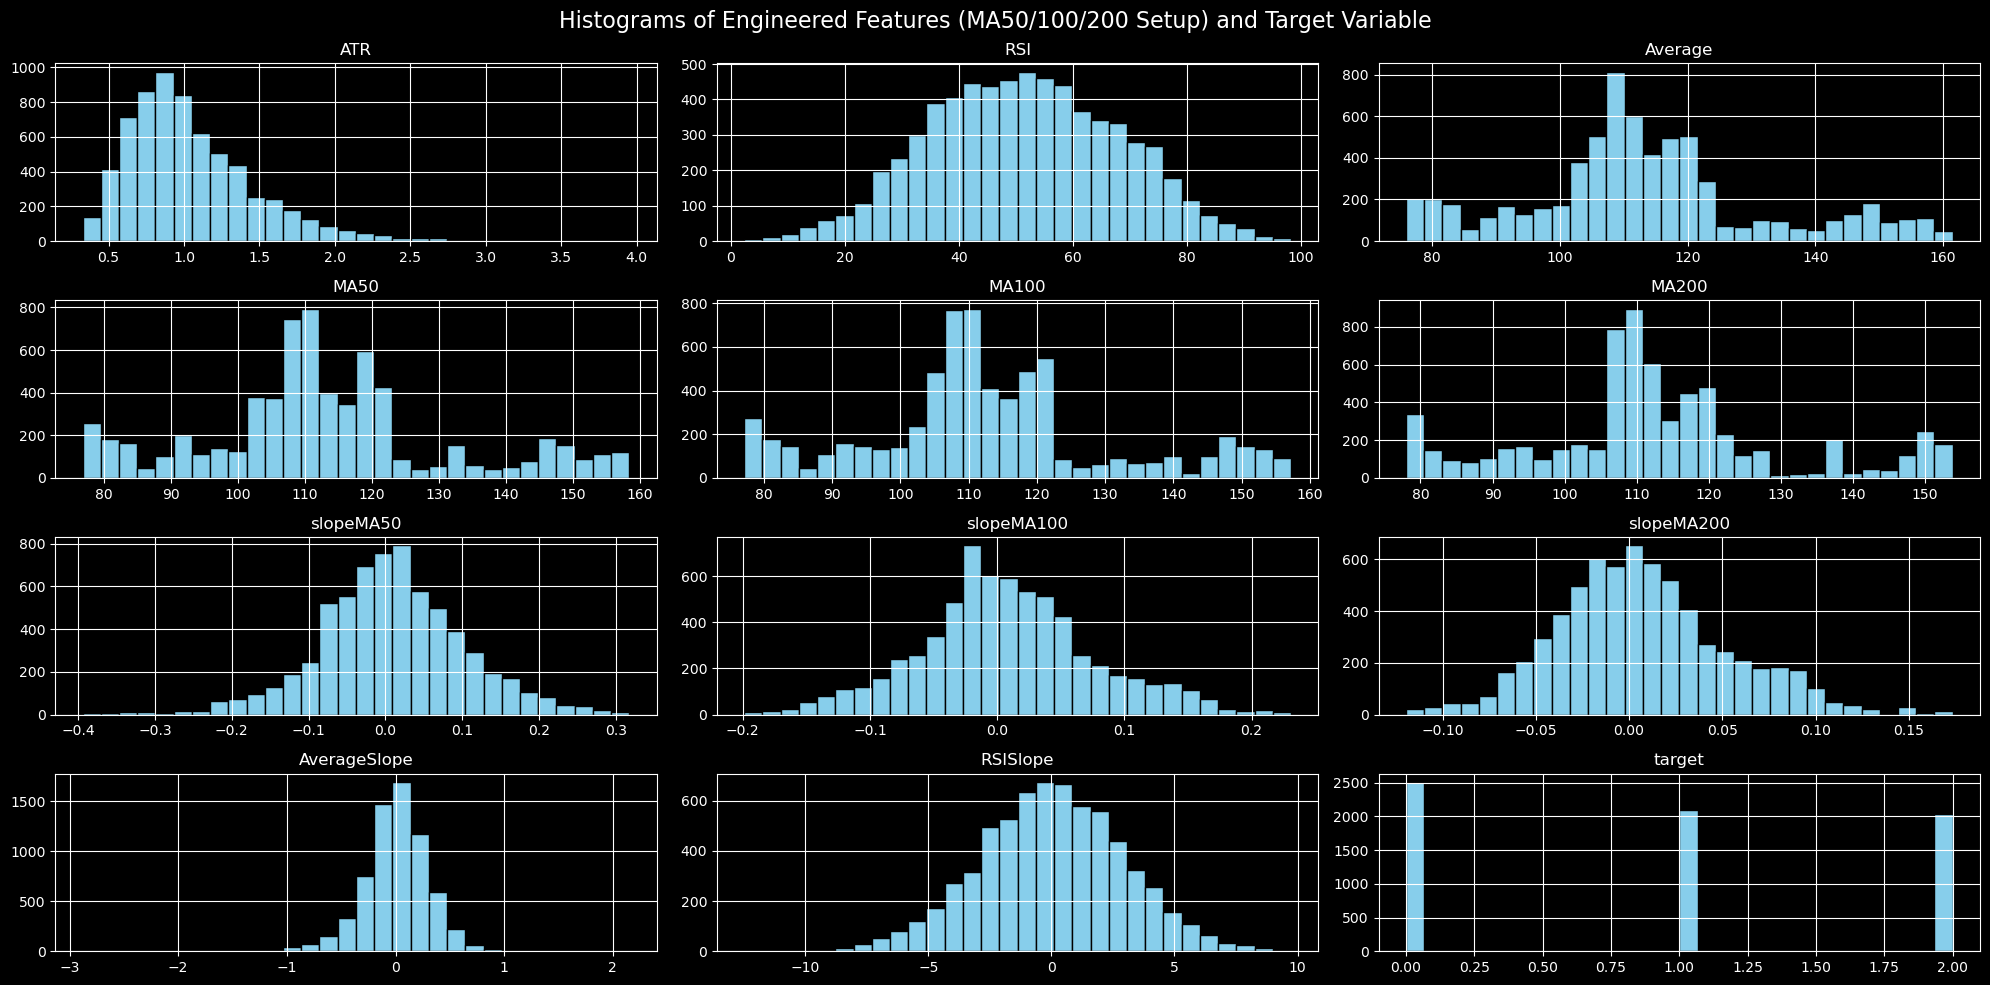

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress



# 1. HELPER FUNCTIONS: SLOPE & ATR

def get_slope(array):
    y = np.array(array)
    x = np.arange(len(y))
    slope = linregress(x, y)[0]
    return slope


def calculate_atr(df, window=14):
    high_low = df["High"] - df["Low"]
    high_cp = (df["High"] - df["Close"].shift(1)).abs()
    low_cp = (df["Low"] - df["Close"].shift(1)).abs()
    tr = pd.concat([high_low, high_cp, low_cp], axis=1).max(axis=1)
    return tr.rolling(window=window).mean()



# 2. FEATURE ENGINEERING (MA50, MA100, MA200 & SLOPINGS)

# Average & Volatility
df["Average"] = (df["Open"] + df["High"] + df["Low"] + df["Close"]) / 4
df["ATR"] = calculate_atr(df, window=14)

# Moving Averages
df["MA50"] = df["Close"].rolling(window=50).mean()
df["MA100"] = df["Close"].rolling(window=100).mean()
df["MA200"] = df["Close"].rolling(window=200).mean()

# Relative Strength Index (RSI - 14)
delta = df["Close"].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df["RSI"] = 100 - (100 / (1 + rs))

# Rolling Slopes (6-period window)
back_rolling_n = 6
df["slopeMA50"] = (
    df["MA50"].rolling(window=back_rolling_n).apply(get_slope, raw=True)
)
df["slopeMA100"] = (
    df["MA100"].rolling(window=back_rolling_n).apply(get_slope, raw=True)
)
df["slopeMA200"] = (
    df["MA200"].rolling(window=back_rolling_n).apply(get_slope, raw=True)
)
df["AverageSlope"] = (
    df["Average"].rolling(window=back_rolling_n).apply(get_slope, raw=True)
)
df["RSISlope"] = (
    df["RSI"].rolling(window=back_rolling_n).apply(get_slope, raw=True)
)


# 3. SELECT FEATURES & PLOT HISTOGRAMS

feature_cols = [
    "ATR",
    "RSI",
    "Average",
    "MA50",
    "MA100",
    "MA200",
    "slopeMA50",
    "slopeMA100",
    "slopeMA200",
    "AverageSlope",
    "RSISlope",
    "target",  # Target column calculated previously
]

# Clean up rolling NaN values
df_model = df[feature_cols].dropna()

# Plot clean distribution grid
fig, ax = plt.subplots(figsize=(20, 10))
df_model.hist(ax=ax, bins=30, edgecolor="black", color="skyblue")

plt.suptitle(
    "Histograms of Engineered Features (MA50/100/200 Setup) and Target Variable",
    fontsize=16,
)
plt.tight_layout()
plt.show()

In [ ]:
Let's also check the distribution of RSI within the different target classes. As we can see, the three distributions seem to follow the same pattern, indicating that relying solely on this feature is unlikely to yield accurate predictions.
To uncover correlations, we will need to combine it with other features.

Using raw price-level features such as Open, High, Low, Close, Average, MA50, MA100, and MA200 
can reduce a model's ability to generalize across different market regimes. 
For example, a K-Nearest Neighbors (KNN) model evaluating a test observation with a USD/JPY price of 155.00 JPY 
would search for historical observations with similar nominal price levels, 
even if those observations occurred under entirely different market conditions. 
As a result, the model may fail to capture the underlying market dynamics, such as momentum, trend strength, and volatility.

To improve model robustness, the analysis focuses on stationary and scale-independent features,
including technical indicators such as the Relative Strength Index (RSI), Average True Range (ATR), 
and moving average slope metrics. These features describe the market's behavior rather than its absolute price level. Consequently,
a market condition characterized by RSI = 62 and MA50 slope > 0.02 is interpreted 
consistently regardless of whether the USD/JPY exchange rate is trading at 105.00 JPY or 155.00 JPY.
This approach enables the machine learning model to learn transferable market patterns and improves
its ability to generalize to unseen data.

**Distribution of RSI across Target Classes**

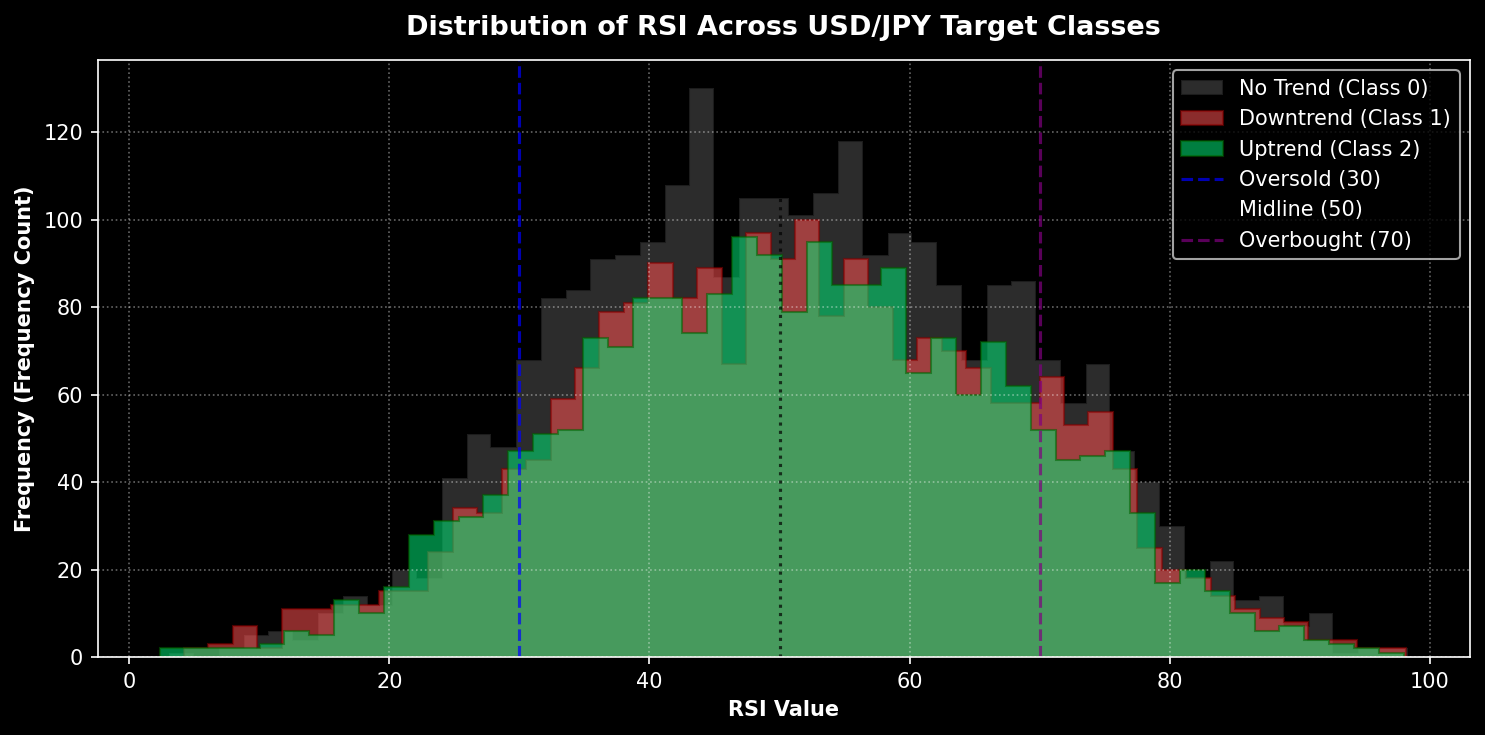

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5), dpi=150)

# Extract RSI by target class
df_unclear = df.RSI[df.target == 0]
df_down = df.RSI[df.target == 1]
df_up = df.RSI[df.target == 2]

# Plot overlapping histograms with step contours for clarity
plt.hist(
    df_unclear,
    bins=50,
    alpha=0.35,
    color="gray",
    label="No Trend (Class 0)",
    histtype="stepfilled",
    edgecolor="black",
)
plt.hist(
    df_down,
    bins=50,
    alpha=0.55,
    color="#FF5252",
    label="Downtrend (Class 1)",
    histtype="stepfilled",
    edgecolor="darkred",
)
plt.hist(
    df_up,
    bins=50,
    alpha=0.55,
    color="#00E676",
    label="Uptrend (Class 2)",
    histtype="stepfilled",
    edgecolor="darkgreen",
)

# Reference lines for standard RSI thresholds
plt.axvline(30, color="blue", linestyle="--", alpha=0.7, label="Oversold (30)")
plt.axvline(50, color="black", linestyle=":", alpha=0.7, label="Midline (50)")
plt.axvline(70, color="purple", linestyle="--", alpha=0.7, label="Overbought (70)")

plt.title(
    "Distribution of RSI Across USD/JPY Target Classes",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
plt.xlabel("RSI Value", fontsize=10, fontweight="bold")
plt.ylabel("Frequency (Frequency Count)", fontsize=10, fontweight="bold")
plt.legend(loc="upper right", frameon=True)
plt.grid(True, linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
# Splitting features and target

In [28]:
# Clean missing values from rolling indicator windows
df_model = df.dropna()

# Select stationary indicators + trend features
features = [
    "ATR","RSI","Average","MA50","MA100","MA200","slopeMA50","slopeMA100","slopeMA200","AverageSlope","RSISlope",
]

# Separate features (X) and target label (y)
X = df_model[features]
y = df_model["target"]

# Display top 5 rows of feature matrix
X.head()

,ATR,RSI,Average,MA50,MA100,MA200,slopeMA50,slopeMA100,slopeMA200,AverageSlope,RSISlope
Date,,,,,,,,,,,
2000-10-13,0.732142,50.626509,107.709999,107.5296,107.3463,107.24335,-0.018531,0.007031,0.019550,-0.276000,-4.353695
2000-10-16,0.747142,57.074300,107.880001,107.5106,107.3578,107.25785,-0.018331,0.005926,0.015463,-0.182429,-2.746950
2000-10-17,0.727143,58.333349,108.022501,107.4974,107.3721,107.26730,-0.016091,0.007149,0.013199,-0.021071,-0.351301
2000-10-18,0.747143,50.127905,107.822502,107.4922,107.3724,107.27705,-0.014326,0.008146,0.011790,0.037143,-0.226578
2000-10-19,0.750000,52.439081,108.037500,107.5048,107.3707,107.28860,-0.009640,0.006974,0.011316,0.058357,0.757927


**Key Observations for KNN Preparation**
  
- **Significant Magnitude Gap:** Features like price averages (107.50) and RSI (52.00) 
   operate on vastly larger scales than slope features (-0.01 to +0.01). 
   Standard scaling via StandardScaler() is essential before training distance-sensitive models like KNN.

- **Feature Selection Strategy:** Because KNN relies on nearest-neighbor distance metrics, including both raw price levels
    (Average, MA50, MA100, MA200)and stationary features (ATR, RSI, slopes) 
   can lead to price levels dominating distance calculations. 
       
Evaluating model performance both with and without raw price features will reveal which combination generalizes best.

# Splitting train and validation sets

In [ ]:
The dataset is divided using a time-based split, with the first 80% of the observations used for training and
the remaining 20% reserved for validation. Unlike random sampling, this approach preserves 
the chronological order of the data, preventing data leakage and ensuring that 
the model is evaluated on unseen future observations.
This method provides a realistic assessment of the KNN model's 
ability to predict market trends under real-world trading conditions.

In [29]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# 1. 80/20 Chronological Split
split = int(0.8 * len(X))
X_train, X_valid = X[:split], X[split:]
y_train, y_valid = y[:split], y[split:]

# 2. Scale + Fit KNN
model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
model.fit(X_train, y_train)

# 3. Print Results
print(f"Train Accuracy: {model.score(X_train, y_train):.2%}")
print(f"Valid Accuracy: {model.score(X_valid, y_valid):.2%}")

Train Accuracy: 58.11%
Valid Accuracy: 36.73%


# KNN Classifier
Let's try with a simple KNN classifier baseline. I have optimized the parameters upstream with a search grid.

In [30]:
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Define KNN hyperparameters
knn_params = {
    "n_neighbors": 225,
    "weights": "uniform",
    "algorithm": "ball_tree",
    "leaf_size": 30,
    "p": 1,
    "metric": "minkowski",
    "metric_params": None,
    "n_jobs": 1,
}

# Wrap model with StandardScaler to ensure valid distance calculations
model = make_pipeline(StandardScaler(), KNeighborsClassifier(**knn_params))
model.fit(X_train, y_train)

# Generate predictions
y_pred_train = model.predict(X_train)
y_pred_valid = model.predict(X_valid)

# Benchmarks: Random guess ("gambler") & Zero-rule majority class ("base")
np.random.seed(42)  # For reproducible random predictions
gambler_pred = np.random.choice([0, 1, 2], len(y_pred_valid))
base_accuracy = (df_model.target.value_counts() / len(df_model)).max()

# Metrics
train_accuracy = accuracy_score(y_train, y_pred_train)
valid_accuracy = accuracy_score(y_valid, y_pred_valid)
gambler_accuracy = accuracy_score(y_valid, gambler_pred)

print(f"Train accuracy:   {train_accuracy * 100 :.2f}%")
print(f"Valid accuracy:   {valid_accuracy * 100 :.2f}%")
print(f"Gambler accuracy: {gambler_accuracy * 100 :.2f}%")
print(f"Base accuracy:    {base_accuracy * 100 :.2f}%")

print("\nClass Distribution:")
print(df_model.target.value_counts(normalize=True).sort_index())

print(
    f"\n=== Accuracy improvement over baseline: {(valid_accuracy - base_accuracy) * 100 :.2f}% ==="
)

Train accuracy:   38.71%
Valid accuracy:   42.01%
Gambler accuracy: 34.16%
Base accuracy:    37.83%

Class Distribution:
target
0    0.378281
1    0.315837
2    0.305882
Name: proportion, dtype: float64

=== Accuracy improvement over baseline: 4.18% ===


Performance 
- **No Overfitting:** Train accuracy (38.71%) and Validation accuracy (42.01%) are closely aligned, 
    meaning the model is generalizing rather than memorizing noise.

- **Beating Benchmarks:** The model achieves a +4.18% gain over the baseline majority class (37.83%) 
    and outpaces random guessing (34.16%).
        
- **Real Technical Signal:** In financial market modeling, achieving a 42% multi-class directional
    accuracy across 3 outcomes (where pure chance is approx 33.3%) confirms that the engineered 
     features (RSI, ATR, and slope metrics) carry predictive signal.

# Save the model

In [ ]:
save the model to reuse it later.

In [ ]:
filename = 'model.sav'
joblib.dump(model, filename)
loaded_model = joblib.load(filename)

# Cross Validation

To obtain a more reliable estimate of model performance, time-series cross-validation is used instead of a single train-validation split.
Unlike traditional cross-validation, this approach preserves the chronological order of the data, 
ensuring that the model is always trained on historical observations and tested on future data, 
thereby preventing data leakage. By evaluating the model across multiple sequential splits, 
time-series cross-validation provides a more robust assessment of its generalization ability
and performance under different market conditions.

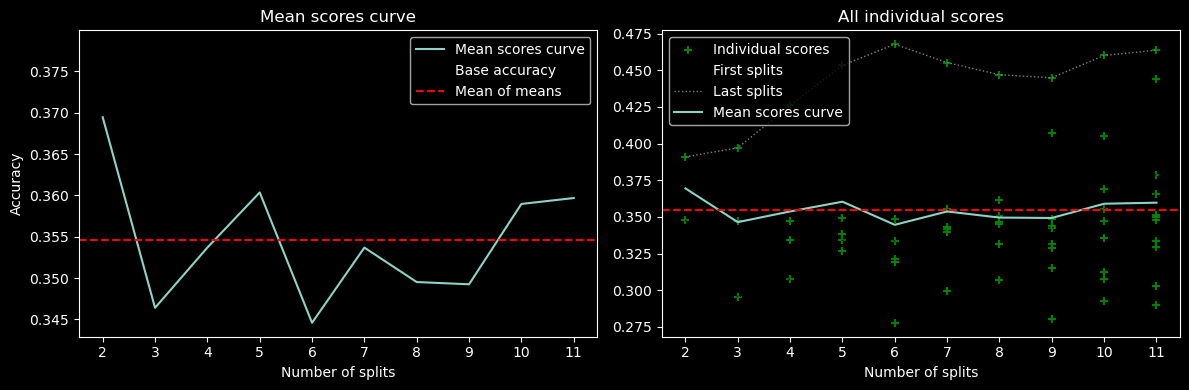

=== Accuracy improvement: -2.37% ===


In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.neighbors import KNeighborsClassifier

n_splits_range = range(2, 12)

# Structures to track scores cleanly
mean_scores = []
first_fold_scores = []
last_fold_scores = []
all_n_splits = []
all_scores = []

for n_splits in n_splits_range:
    tscv = TimeSeriesSplit(n_splits=n_splits)
    split_scores = []
    
    for train_index, test_index in tscv.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        model = KNeighborsClassifier(**knn_params)
        model.fit(X_train, y_train)
        score = model.score(X_test, y_test)
        
        split_scores.append(score)
        all_n_splits.append(n_splits)
        all_scores.append(score)
        
    # Directly grab the first and last split for this specific n_splits
    first_fold_scores.append(split_scores[0])
    last_fold_scores.append(split_scores[-1])
    mean_scores.append(np.mean(split_scores))

# Display
plt.figure(figsize=(12, 4))

# Plot 1: Mean Scores
plt.subplot(1, 2, 1)
plt.plot(n_splits_range, mean_scores, label="Mean scores curve")
plt.axhline(base_accuracy, color='black', ls='--', label="Base accuracy")
plt.axhline(np.mean(mean_scores), color='red', ls='--', label="Mean of means")
plt.xticks(n_splits_range)
plt.title("Mean scores curve")
plt.xlabel("Number of splits")
plt.ylabel("Accuracy")
plt.legend()

# Plot 2: All Individual Scores
plt.subplot(1, 2, 2)
plt.scatter(all_n_splits, all_scores, marker='+', color='green', label="Individual scores")
plt.plot(n_splits_range, first_fold_scores, lw=1, ls=':', color='black', label="First splits")
plt.plot(n_splits_range, last_fold_scores, lw=1, ls=':', color='gray', label="Last splits")
plt.plot(n_splits_range, mean_scores, label="Mean scores curve")
plt.axhline(base_accuracy, color='black', ls='--')
plt.axhline(np.mean(mean_scores), color='red', ls='--')
plt.xticks(n_splits_range)
plt.title("All individual scores")
plt.xlabel("Number of splits")
plt.legend()

plt.tight_layout()
plt.show()

acc_improvement = (np.mean(mean_scores) - base_accuracy) * 100
print(f"=== Accuracy improvement: {acc_improvement:.2f}% ===")

In [ ]:
A -2.37% drop in accuracy means your model performs worse under Time Series Cross-Validation than your initial baseline score suggested. 
This is actually a very common trap in time series modeling, and it usually boils down to one of two main causes:

In [ ]:
REFERENCE
Trend Predictions - Classic ML approach

